<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#EAE2C6;font-family:Verdana, sans-serif;color:#6D2323;font-size:150%;text-align:center;border-radius:10px;padding:10px;">    📦 Supply Chain Data Analysis   </p>


### NB. Data was processed and cleaned previously in another notebook.
https://github.com/AmlSoliman2025/-SCMS-Supply-Chain-Data-Cleaning-Analysis/blob/main/SCMS%20cleaning.ipynb


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#EAE2C6;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  </p>

### Data Analysis Steps
- **Explore**: what's in the data?
- **Describe**: how does it behave?
- **Diagnose**: where are the problems?

In [2]:
# 📌 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



#Load the dataset
df = pd.read_csv(r"D:\aml\project\last choice\NEW\cleaned_data.csv")  

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#EAE2C6;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  </p>

# EDA and Data Distribution 

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  </p>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10324 non-null  int64  
 1   project code                  10324 non-null  object 
 2   pq #                          10324 non-null  object 
 3   po / so #                     10324 non-null  object 
 4   asn/dn #                      10324 non-null  object 
 5   country                       10324 non-null  object 
 6   managed by                    10324 non-null  object 
 7   fulfill via                   10324 non-null  object 
 8   vendor inco term              10324 non-null  object 
 9   shipment mode                 10324 non-null  object 
 10  pq first sent to client date  7643 non-null   object 
 11  po sent to vendor date        8393 non-null   object 
 12  scheduled delivery date       10324 non-null  object 
 13  d

In [4]:
statistics_overview = df.describe( ).T
statistics_overview 

,count,mean,std,min,25%,50%,75%,max
id,10324.0,51098.968229,31944.332496,1.0,12795.750000,57540.500000,83648.250000,8.682300e+04
unit of measure (per pack),10324.0,77.990895,76.579764,1.0,30.000000,60.000000,90.000000,1.000000e+03
line item quantity,10324.0,18332.534870,40035.302961,1.0,408.000000,3000.000000,17039.750000,6.199990e+05
line item value,10324.0,157650.567347,345292.066979,0.0,4314.592500,30471.465000,166447.140000,5.951990e+06
pack price,10324.0,21.910241,45.609223,0.0,4.120000,9.300000,23.592500,1.345640e+03
unit price,10324.0,0.611701,3.275808,0.0,0.080000,0.160000,0.470000,2.386500e+02
weight (kilograms),10324.0,2699.627517,10937.883547,0.0,75.000000,575.135144,2523.000000,8.573540e+05
freight cost (usd),8870.0,11673.565415,23341.216397,0.0,1570.462958,4957.905000,13583.888640,8.260590e+05
line item insurance (usd),10324.0,234.582169,494.270775,0.0,7.147500,42.815000,241.750000,7.708440e+03
pq_to_po_days,7643.0,39.704697,65.393815,-224.0,24.000000,24.000000,24.500000,4.140000e+02


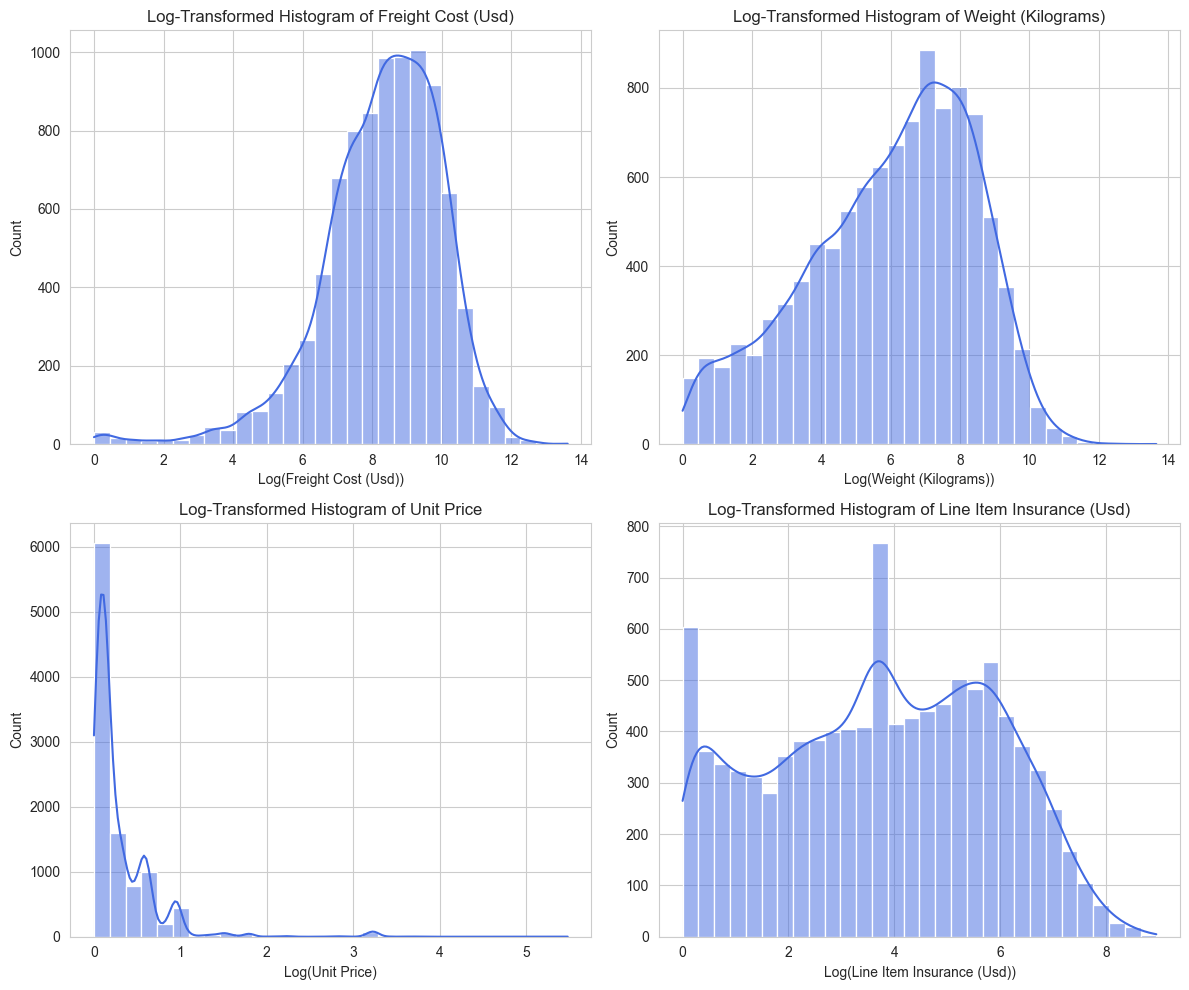

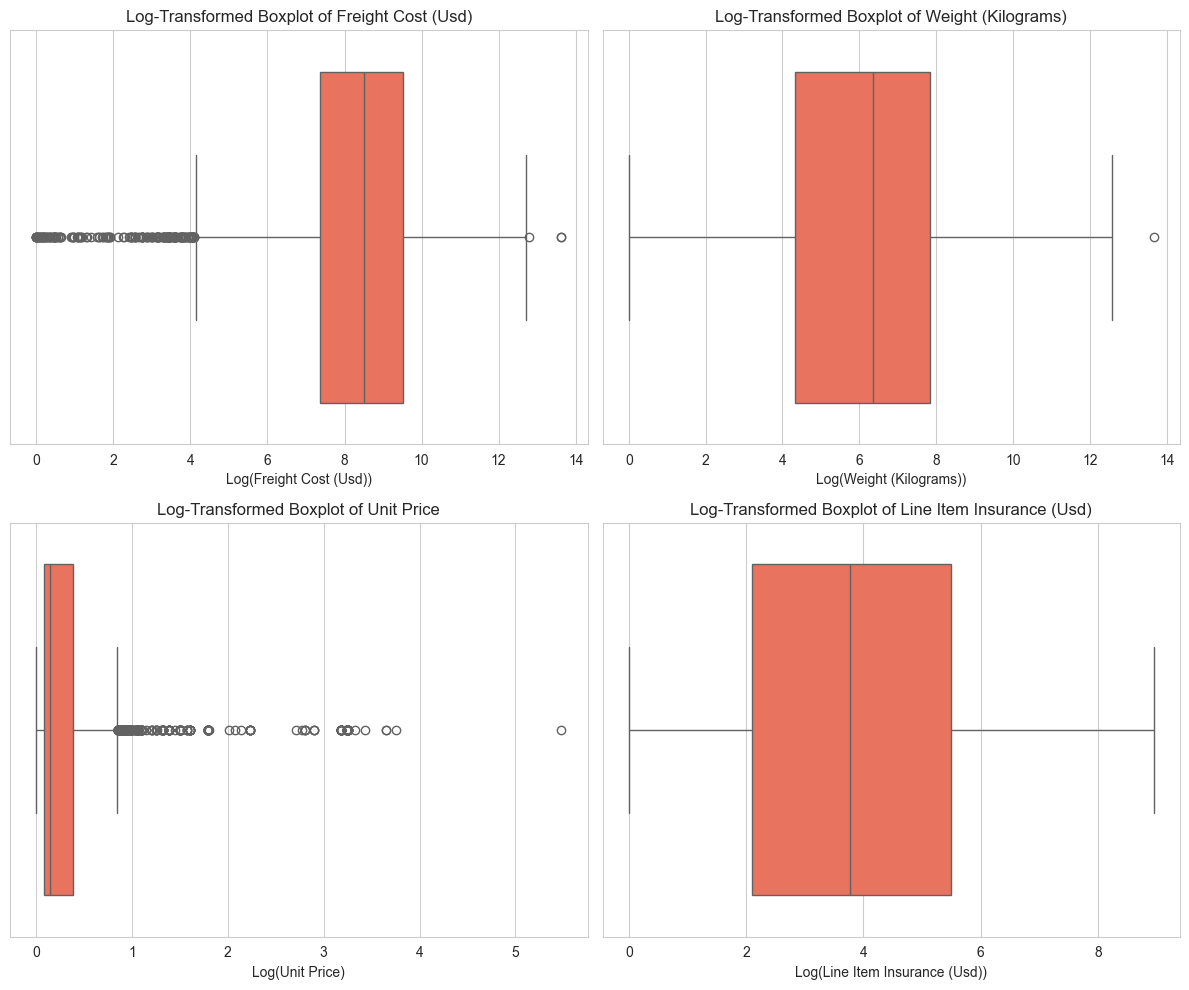

In [5]:
####### Log Transformation for Normalization (to reduce skewness) #######

# List of numerical columns to visualize
num_cols = ["freight cost (usd)", "weight (kilograms)", "unit price", 
            "line item insurance (usd)", "line item value", "pack price", "line item quantity"]

# Apply log transformation (log1p to handle zeros)
log_df = df.copy()
for col in num_cols:
    log_df[col] = np.log1p(df[col])  # log1p ensures log(0) doesn't cause issues

# Set plot style
sns.set_style("whitegrid")

###  Histograms (Log Transformed)**
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(log_df[col], bins=30, kde=True, ax=ax, color="royalblue")
    ax.set_title(f"Log-Transformed Histogram of {col.replace('_', ' ').title()}")
    ax.set_xlabel(f"Log({col.replace('_', ' ').title()})")

plt.tight_layout()
plt.show()

###  Boxplots (Log Transformed)**
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=log_df[col], ax=ax, color="tomato")
    ax.set_title(f"Log-Transformed Boxplot of {col.replace('_', ' ').title()}")
    ax.set_xlabel(f"Log({col.replace('_', ' ').title()})")

plt.tight_layout()
plt.show()


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#6D2323;font-size:150%;text-align:center;border-radius:10px;padding:10px;"> Insights </p>

High variability: Metrics like line item quantity, value, weight, and freight cost show large spreads → expected due to commodity diversity, including RDC items.

Zeros in key fields:

     freight cost = 0 is valid   because cost is bundled into commodity price or RDC shipments.

     unit price = 0 could result from low-value items priced via pack price.

     insurance = 0 may relate to Incoterms or RDC transactions.

Negative values in pq_to_po_days: Likely due to RDC lead time setups or system timestamps.

Missing data: Fields like freight cost and pq_to_po_days have nulls —>> RDC transactions.

Outliers: Large values (e.g., weight > 800,000 kg) are acceptable for specific bulk commodities.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  </p>

In [6]:
df.describe( include= object).T

,count,unique,top,freq
project code,10324,142,116-ZA-T30,768
pq #,10324,1237,Pre-PQ Process,2681
po / so #,10324,6233,SCMS-199289,67
asn/dn #,10324,7030,ASN-19166,54
country,10324,43,South Africa,1406
managed by,10324,4,PMO - US,10265
fulfill via,10324,2,From RDC,5404
vendor inco term,10324,8,N/A - FROM RDC,5404
shipment mode,10324,4,Air,6473
pq first sent to client date,7643,763,2014-09-11,205


Vendor, fulfill via, and vendor inco term show RDC dominance, which aligns with earlier findings (e.g., zero freight, short lead times).

Most records are **ARV** products, primarily adult and generic, with frequent mentions of Efavirenz.

Freight-related info in freight cost (usd)_original confirms that costs are often included in commodity price ->> 0 values are common.

Date fields are consistent and ready for lead time analysis since converted to datetime

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#6D2323;font-size:150%;text-align:center;border-radius:10px;padding:10px;"> Summary Statistics </p>


📊 ***Summary Statistics*** 

– Cleaned Supply Chain Data

The summary statistics provide valuable insights into the cleaned dataset of 10,324 records. Below are the key observations:

🔢 General Distribution

Most numerical columns are right-skewed (mean > median), so **medians** are more appropriate for analysis than means.

🗂️ Project, Country & Management

      142 unique project codes indicate a diverse project portfolio.

      Operations span 43 countries, with South **Africa** being most represented.

      4 managers, with PMO - US managing 10,265 records, dominate operations.

📦 Delivery Metrics

      Delivery Delay: Mean ≈ -6.02 days → suggests some early deliveries or timestamp issues.



💰 Cost Metrics

      Total Order Value: Median ≈ 4,365.19, max = 686,000 → wide variability in order size.

      Freight Cost per KG: Median = 3,868.37 → suggests outliers or high-cost routes.


⏱️ Vendor & Lead Times

      Vendor Lead Time: Avg ≈ 39.70 days → may offer opportunities for optimization.

      RDC-related delays and negative lags likely tied to special handling or system logic.

💊 Products & Commodities

      7030 out of 10324 records are first-line products → high-priority or essential items.

      ARVs (Antiretroviral Drugs) dominate the dataset with 8,550 records, followed by HRDTs and ACTs.

      Commodities span 6 subcategories, produced under 48 different brands.



<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#6D2323;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  ⏱️ Time Frame  </p>

In [ ]:

df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')


start_date = df['delivered to client date'].min().date()
end_date = df['delivered to client date'].max().date()

print(f"✅ Data cover period from {start_date} To {end_date}")



✅ Data cover period from 2006-05-02 To 2015-09-14


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#6D2323;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  ⏱️ Projects Per Year </p>

In [8]:
df['delivery_year'] = df['delivered to client date'].dt.year

# count of projects per year
projects_per_year = df.groupby('delivery_year')['project code'].nunique()
projects_per_year

delivery_year
2006    13
2007    24
2008    35
2009    56
2010    30
2011    43
2012    49
2013    37
2014    37
2015    35
Name: project code, dtype: int64

C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\353296577.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=projects_per_year, x='Year', y='Number of Projects', palette='Blues_d')


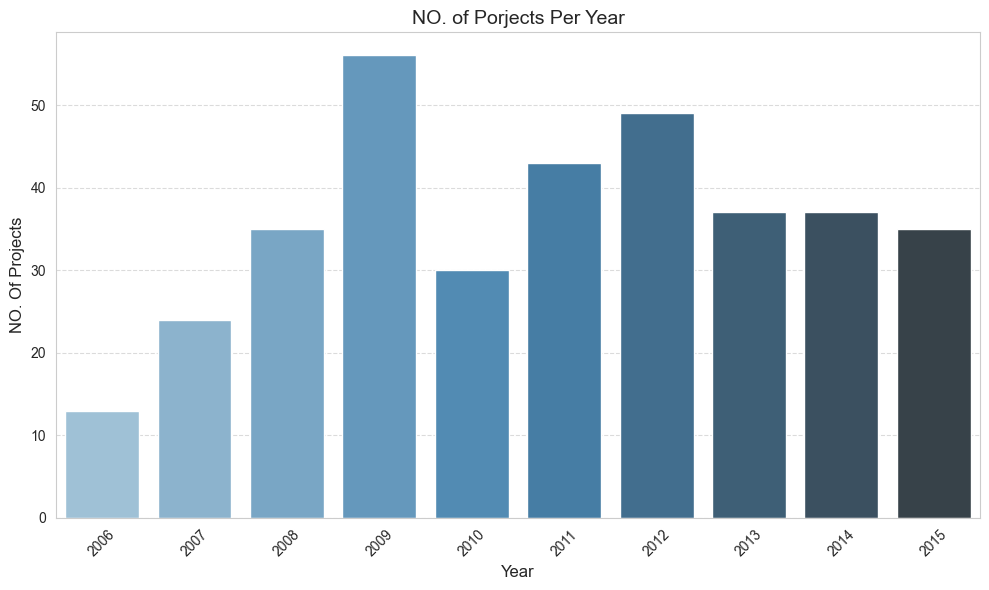

In [9]:

df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')
df['delivery_year'] = df['delivered to client date'].dt.year

projects_per_year = df.groupby('delivery_year')['project code'].nunique().reset_index()
projects_per_year.columns = ['Year', 'Number of Projects']

plt.figure(figsize=(10, 6))
sns.barplot(data=projects_per_year, x='Year', y='Number of Projects', palette='Blues_d')

plt.title('NO. of Porjects Per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('NO. Of Projects', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


 The number of project codes increased significantly from 2006 to 2009, peaking in 2009 with 56 projects. Although there was a drop in 2010, the numbers remained relatively high and stable through 2015, fluctuating between 30 and 49 projects annually. This trend suggests sustained project activity over the decade, with 2009 marking the peak year.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#6D2323;font-size:150%;text-align:center;border-radius:10px;padding:10px;"> Projects Per Year And Countries </p>

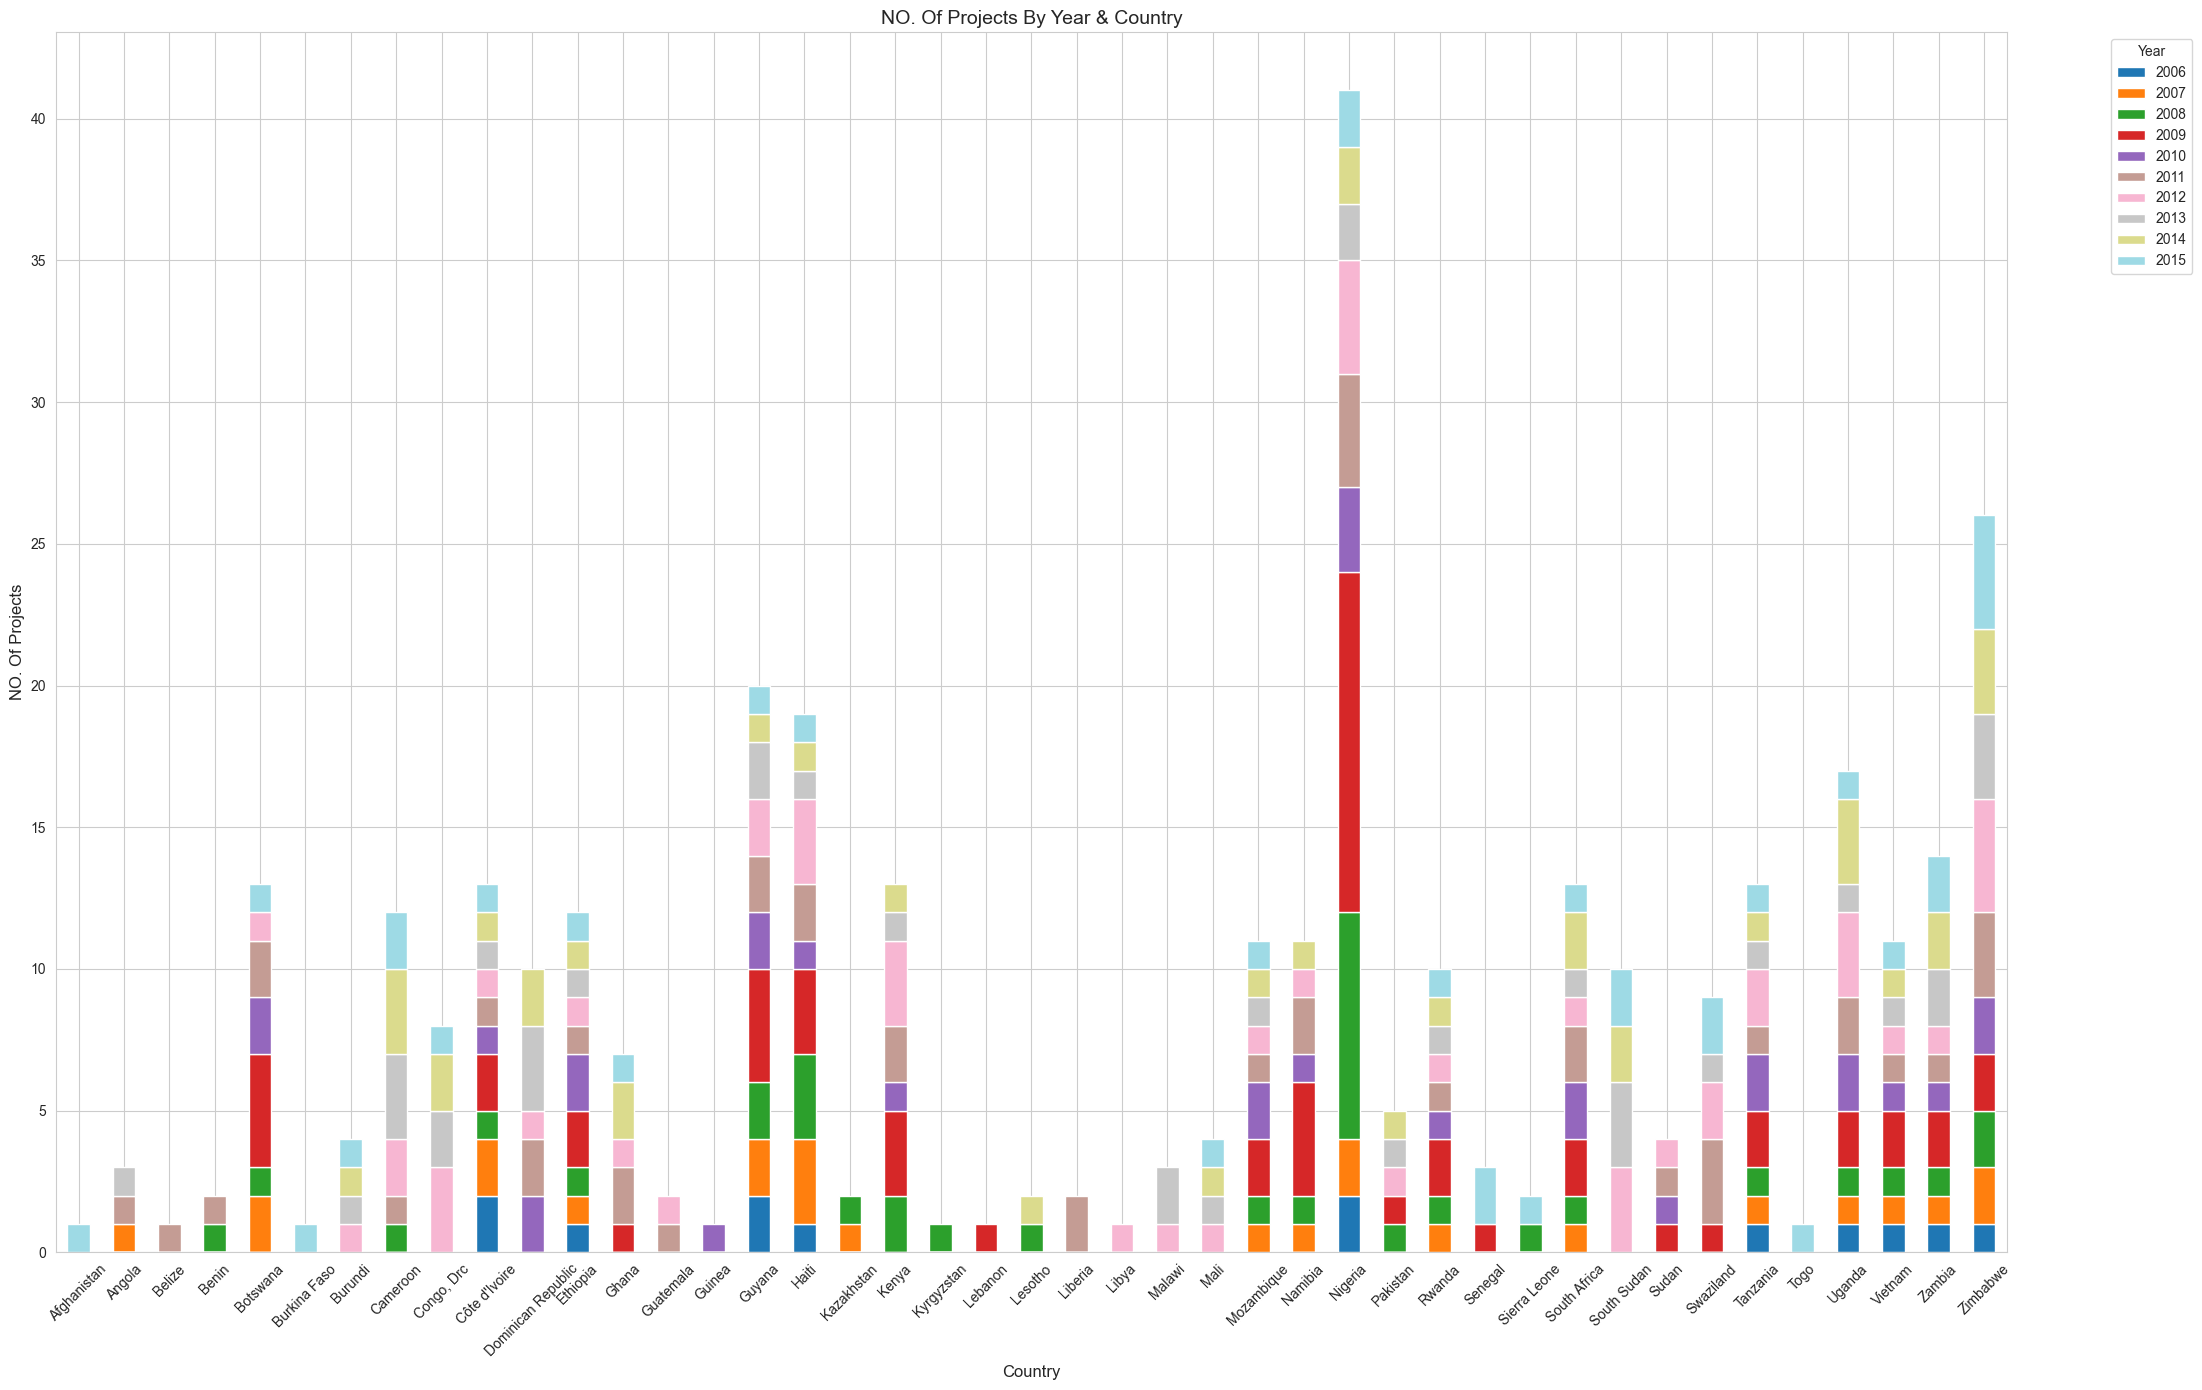

In [10]:
projects_country_year = (
    df.groupby(['country', 'delivery_year'])['project code']
    .nunique()
    .reset_index()
    .rename(columns={'project code': 'number_of_projects'})
)


stacked_by_country = projects_country_year.pivot(
    index='country',
    columns='delivery_year',
    values='number_of_projects'
).fillna(0)

 
stacked_by_country.plot(kind='bar', stacked=True, figsize=(22, 14), colormap='tab20')

plt.title('NO. Of Projects By Year & Country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('NO. Of Projects', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


There's a significant variation in the number of projects across countries.

Nigeria appears to have the highest number of projects over the given years, followed by Zimbabwe

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  </p>

In [11]:
#Need some calculations to go through our goals

 #1- Date based calculations >>> (These help in evaluating supply chain efficiency)

# 1. covert to datetime
date_cols = ['delivered to client date', 'scheduled delivery date', 'po sent to vendor date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')



df['delivery_delay'] = (df['delivered to client date'] - df['scheduled delivery date']).dt.days

# 2. specify filter
mask = df['valid_timeline'] == True

df.loc[mask, 'scheduled_lead_time'] = (
    df.loc[mask, 'scheduled delivery date'] -
    df.loc[mask, 'po sent to vendor date']
).dt.days

 
df.loc[mask, 'delivery_lead_time'] = (
    df.loc[mask, 'delivered to client date'] -
    df.loc[mask, 'po sent to vendor date']
).dt.days



 #2-Order Metrics >>>(These are useful for tracking supply chain performance.

 #3- Logistics & Cost Metrics >>>(These help assess transportation efficiency and cost-effectiveness)

 #4-Supplier Performance Metrics >>>(These identify inefficiencies in vendor processes)


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#6D2323;font-size:150%;text-align:center;border-radius:10px;padding:10px;"> Delivery Delay </p>

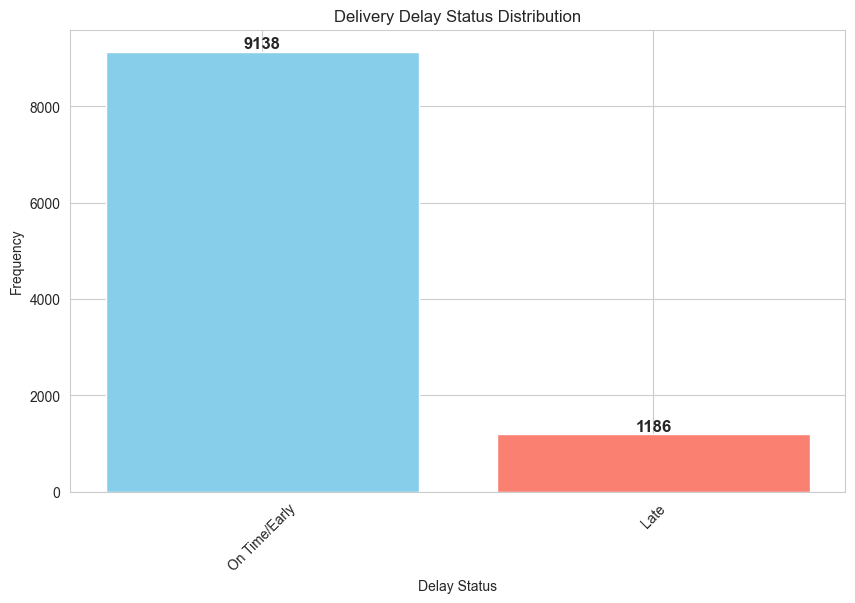

In [12]:
df["delay_status"] = np.where(df["delivery_delay"] > 0, "Late", "On Time/Early")

plt.figure(figsize=(10, 6)) 
plt.title("Delivery Delay Status Distribution")
plt.xlabel("Delay Status")
plt.ylabel("Frequency")
plt.xticks(rotation=45) 
plt.bar(df["delay_status"].value_counts().index, df["delay_status"].value_counts(), color=["skyblue", "salmon"])

delay_counts = df["delay_status"].value_counts()
bars = plt.bar(delay_counts.index, delay_counts.values, color=["skyblue", "salmon"])


for bar in bars:
    height = bar.get_height()  
    plt.text(bar.get_x() + bar.get_width()/2, height, str(int(height)), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

### On-Time/Early Dominance: The vast majority of shipments (over 9,000) arrived on time or early, representing strong logistics performance.

### Delay Incidence: Approximately 1,186 shipments were delayed, indicating a ~12% delay rate (1,186 / (9,000 + 1,186)).

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#16404D;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  🔶 1. Order Lifecycle

Explore → Describe → Diagnose </p>



In [13]:


# Filter only valid timeline entries

date_cols = ['pq first sent to client date', 'po sent to vendor date', 'delivery recorded date']
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')

# 1. delivery_lead_time = PO to Delivery Recorded
df.loc[mask, 'delivery_lead_time'] = (
    df.loc[mask, 'delivery recorded date'] -
    df.loc[mask, 'po sent to vendor date']
).dt.days

# 2. order_cycle_time = PQ to Delivery Recorded
df.loc[mask, 'order_cycle_time'] = (
    df.loc[mask, 'delivery recorded date'] -
    df.loc[mask, 'pq first sent to client date']
).dt.days

# 3. order_processing_time = PQ to PO
df.loc[mask, 'order_processing_time'] = (
    df.loc[mask, 'po sent to vendor date'] -
    df.loc[mask, 'pq first sent to client date']
).dt.days

# 4. total_order_value = quantity * unit price
# 4. Total order value
df['total_order_value'] = df['line item quantity'] * df['unit price']



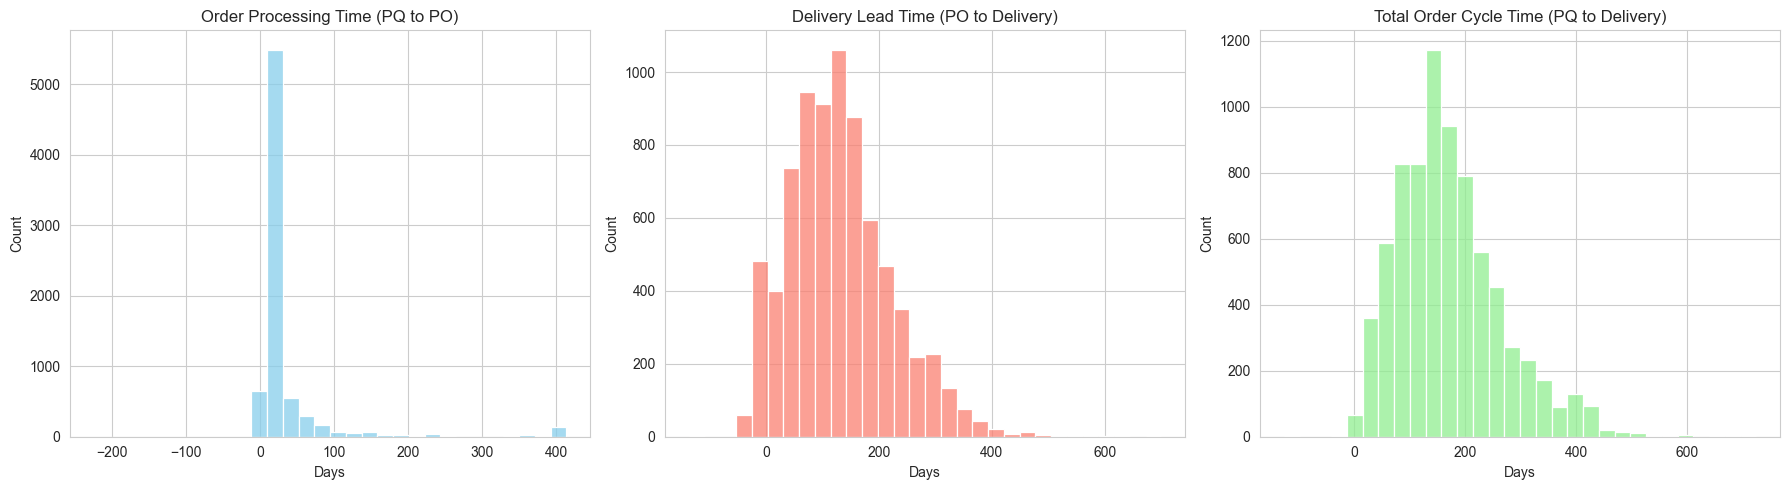

In [14]:


# Filter valid records only
df_valid = df[df['valid_timeline'] == True].copy()

# Plot distribution of each timeline metric
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_valid['order_processing_time'], bins=30, ax=axes[0], color='skyblue')
axes[0].set_title("Order Processing Time (PQ to PO)")
axes[0].set_xlabel("Days")

sns.histplot(df_valid['delivery_lead_time'], bins=30, ax=axes[1], color='salmon')
axes[1].set_title("Delivery Lead Time (PO to Delivery)")
axes[1].set_xlabel("Days")

sns.histplot(df_valid['order_cycle_time'], bins=30, ax=axes[2], color='lightgreen')
axes[2].set_title("Total Order Cycle Time (PQ to Delivery)")
axes[2].set_xlabel("Days")

plt.tight_layout()
plt.show()


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;"> Insights </p>


Order Processing Time identifies internal delays (PQ to PO).
      
      Most orders are processed quickly—within 0–30 days, which is good.

      However, there are noticeable outliers with processing times exceeding 100+ days, and even negative values, suggesting potential data quality issues or backdated entries.

Delivery Lead Time isolates logistics/vendor-related delays.

      This stage shows the widest variation, with the bulk of deliveries occurring within 100–200 days.

      A long tail indicates significant delays in some orders, possibly due to vendor delays or logistical constraints.

Order Cycle Time reveals the total duration from request to receipt.

       Most complete order cycles fall between 100–250 days, with a relatively symmetric distribution.

       This suggests that, despite delays in processing or delivery, the overall cycle remains somewhat consistent.

Long cycle durations in specific countries or shipment modes highlight areas needing intervention.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;"> 🕵️ Diagnostic Analysis </p>
 What’s Causing Delays or Long Cycles?
where time is being spent in long-cycle orders and what factors (product group, shipment mode, country) contribute.

C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\3662353846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_lead_by_mode.index, y=avg_lead_by_mode.values, palette='viridis')


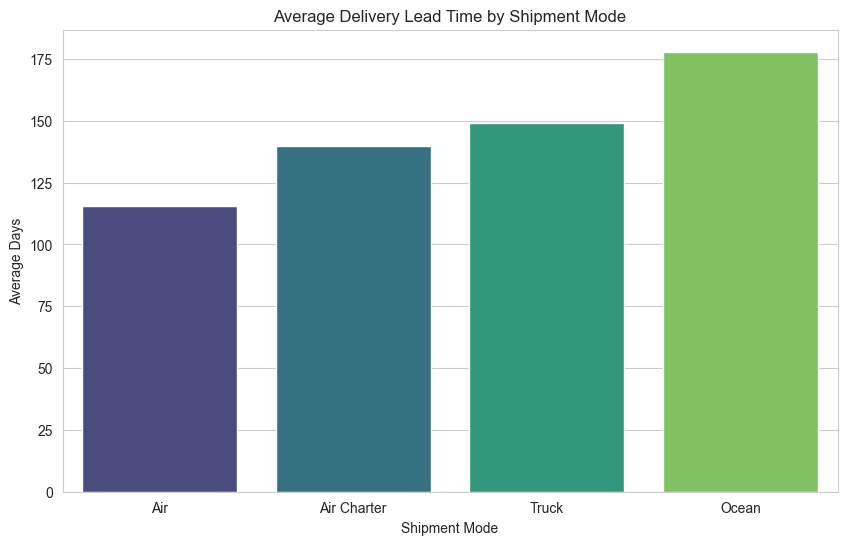

In [16]:
# Average delivery lead time by shipment mode
avg_lead_by_mode = df_valid.groupby('shipment mode')['delivery_lead_time'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_lead_by_mode.index, y=avg_lead_by_mode.values, palette='viridis')
plt.title("Average Delivery Lead Time by Shipment Mode")
plt.ylabel("Average Days")
plt.xlabel("Shipment Mode")
plt.show()


The chart shows that Air shipment has the shortest average delivery lead time, making it the fastest option among the shipment modes. Ocean shipment takes the longest, with an average lead time of over 175 days. Air Charter and Truck fall in between, with Truck being slightly slower than Air Charter. This suggests that while air shipment offers speed, ocean transport significantly extends delivery times and might be better suited for non-urgent or bulk shipments.

C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\4263468455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=long_cycle_countries.values, y=long_cycle_countries.index, palette='magma')


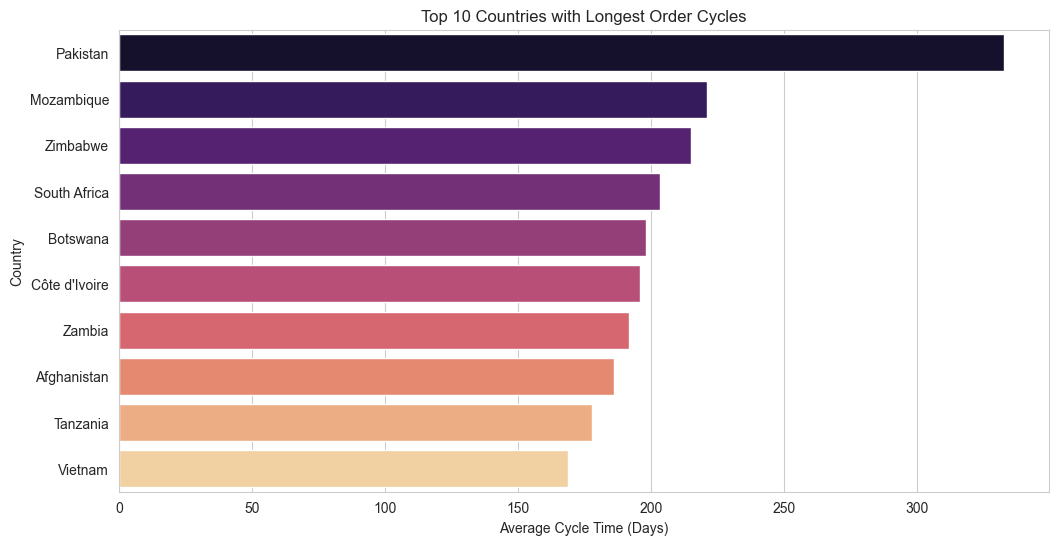

In [17]:
#Identify Long Cycle Countries
# Average order cycle time by country
long_cycle_countries = df_valid.groupby('country')['order_cycle_time'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=long_cycle_countries.values, y=long_cycle_countries.index, palette='magma')
plt.title("Top 10 Countries with Longest Order Cycles")
plt.xlabel("Average Cycle Time (Days)")
plt.ylabel("Country")
plt.show()


The bar chart shows the top 10 countries with the longest average order cycle times, with Pakistan leading by a significant margin.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#16404D;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  🔶 2. Supplier Performance</p>



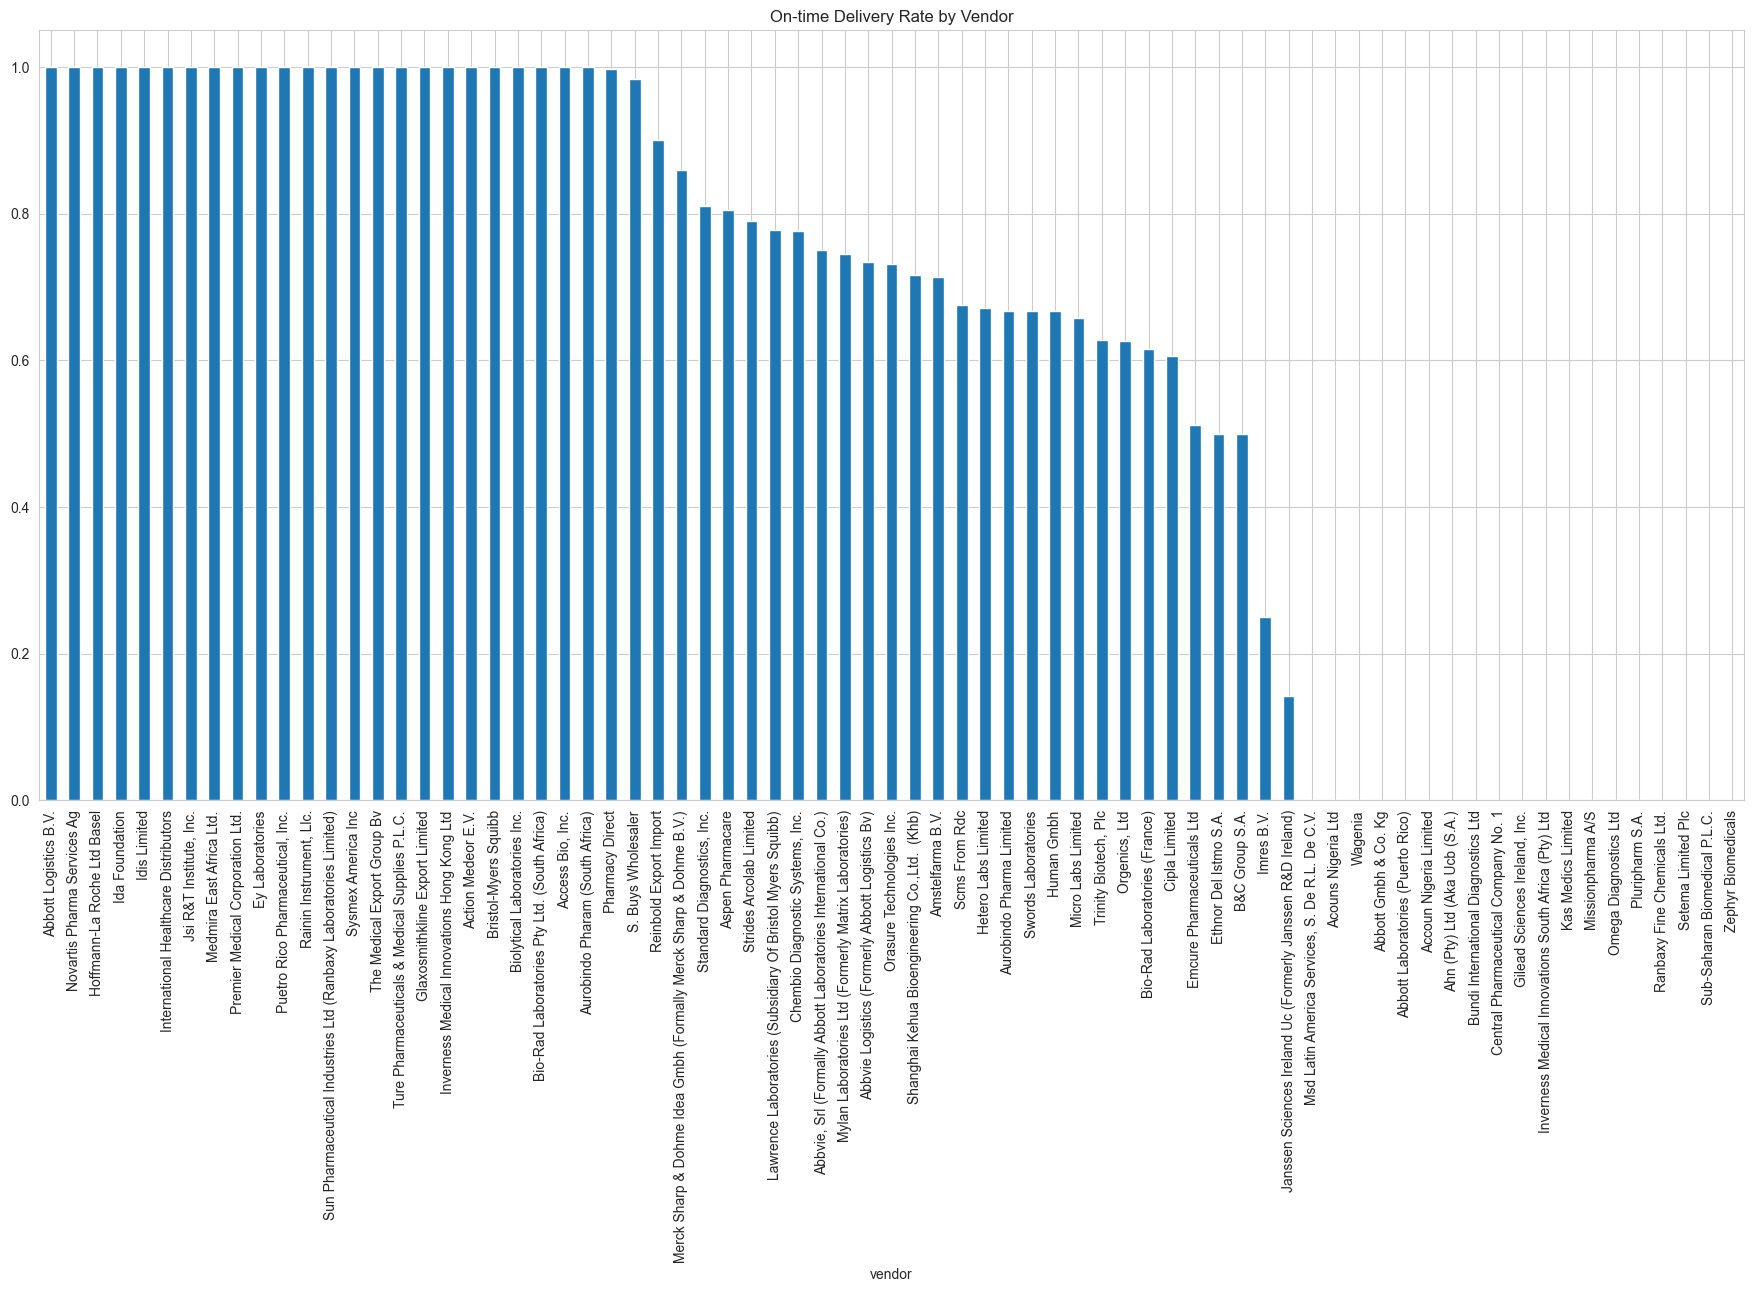

In [18]:
# On-time rate by vendor
df['on_time'] = df_valid['delivery_lead_time'] <=df_valid['scheduled_lead_time']
on_time_rate = df.groupby('vendor')['on_time'].mean().sort_values(ascending=False)
on_time_rate.plot(kind='bar', figsize=(22, 10), title='On-time Delivery Rate by Vendor')
plt.show()

Top Performers: 

     A large group of vendors (left side) maintain a perfect or near-perfect on-time delivery rate (close to 1.0), including **Abbott Logistics B.V.**, **Novartis Pharma Services AG**, and **Pfizer Limited**.

Middle Tier: 

     A noticeable drop begins around the midpoint, where vendors' on-time rates start falling below 0.9, showing potential reliability concerns.

Low Performers: 

     Several vendors at the far right exhibit poor on-time delivery performance (below 0.5), with the lowest around 0.1. These include **Janssen Sciences Ireland UC**, **Sub-Saharan Biogenics**, and **Ranbaxy Fine Chemicals Ltd**.

Improvement Opportunity: 
     Vendors with mid-to-low performance are clear candidates for process improvement or vendor review.

C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\1194577963.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


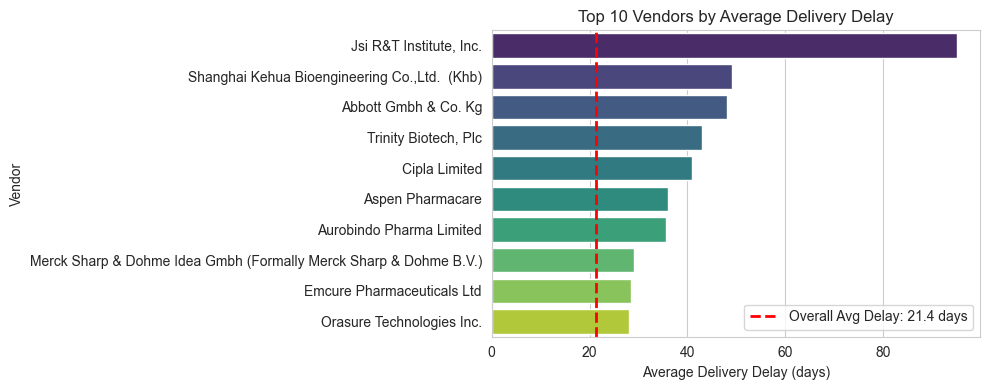

In [19]:


df["delivery_delay"] = pd.to_numeric(df["delivery_delay"], errors="coerce")

filtered_df = df[df["delivery_delay"] > 0]

average_delivery_delay_per_vendor = (
    filtered_df.groupby("vendor")["delivery_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

overall_avg_delay = filtered_df["delivery_delay"].mean()

plt.figure(figsize=(10, 4))
sns.barplot(
    y=average_delivery_delay_per_vendor.index,
    x=average_delivery_delay_per_vendor.values,
    palette="viridis"
)

plt.axvline(overall_avg_delay, color='red', linestyle='--', linewidth=2, label=f'Overall Avg Delay: {overall_avg_delay:.1f} days')

plt.xlabel("Average Delivery Delay (days)")
plt.ylabel("Vendor")
plt.title("Top 10 Vendors by Average Delivery Delay")
plt.legend()
plt.tight_layout()
plt.show()


Vendores with the highest AVG delivery delay are:

      Jsi R&T Istitute >>> more than 90 days delay on average.
      Shanghai Kehua Bioengineering Co., Ltd. and Abbott Gmbth  >>> nearly 50 days delay on average

Scms From RDC has on AVG 20 days delay.

Mylan Laboratories and Sun Pharmatheutical Industries >>> the most reliable suppliers, with average delivery delays of less than 10 days.

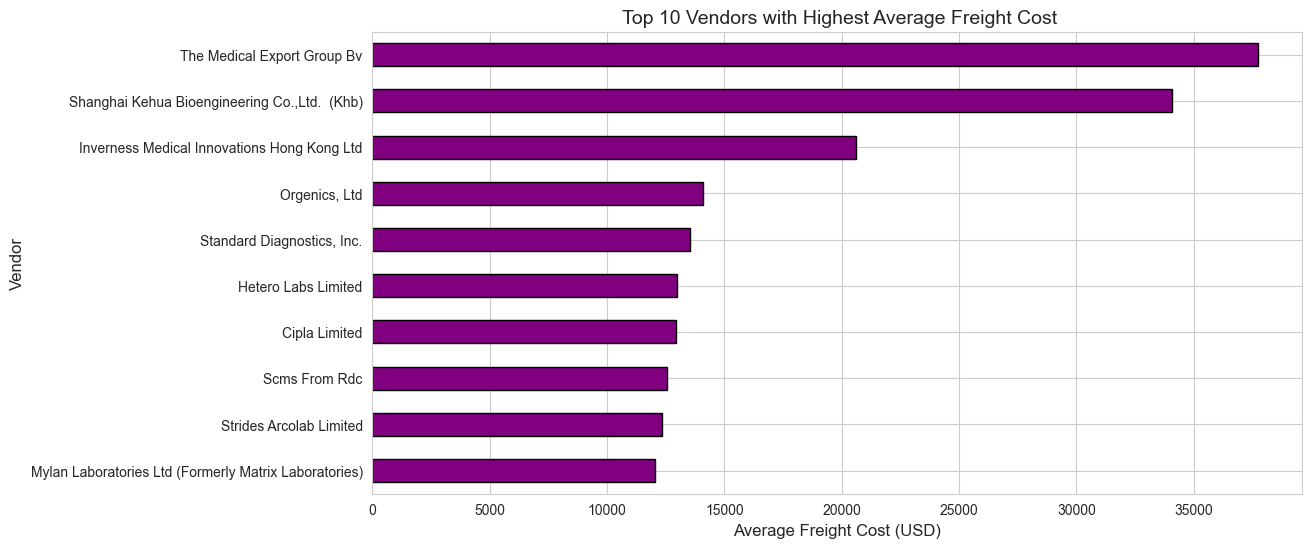

In [20]:
cost_by_vendor = df.groupby("vendor")["freight cost (usd)"].mean().sort_values(ascending=False)

top_10_expensive_vendors = cost_by_vendor.head(10)


plt.figure(figsize=(12, 6))
top_10_expensive_vendors.plot(kind="barh", color="purple", edgecolor="black")


plt.title(" Top 10 Vendors with Highest Average Freight Cost", fontsize=14)
plt.xlabel("Average Freight Cost (USD)", fontsize=12)
plt.ylabel("Vendor", fontsize=12)
plt.gca().invert_yaxis()


plt.show()

Top 3 vendors with the highest freight costs:

    THE MEDICAL EXPORT GROUP BV (≈ $37,000)
    
    SHANGHAI KEHUA BIOENGINEERING CO., LTD. (KHB)

    INVERMESS MEDICAL INNOVATION LTD

Other vendors have notably lower costs, with MYLAN having the lowest in the top 10.

In [21]:
vendor_performance = df.groupby("vendor").agg({
    "delivery_delay": "mean",
    "freight cost (usd)": "mean",
    "line item quantity": "sum"
})

vendor_performance["cost_efficiency"] = vendor_performance["line item quantity"] / vendor_performance["freight cost (usd)"]
vendor_performance.sort_values("cost_efficiency", ascending=False)


,delivery_delay,freight cost (usd),line item quantity,cost_efficiency
vendor,,,,
Scms From Rdc,-8.284049,12545.186864,134609946,10730.007250
Aurobindo Pharma Limited,4.411677,8902.586772,16995950,1909.102426
S. Buys Wholesaler,-28.678322,866.919244,792615,914.289313
Strides Arcolab Limited,0.978495,12356.845602,7985106,646.209094
Mylan Laboratories Ltd (Formerly Matrix Laboratories),-0.615142,12061.980341,7739464,641.641238
...,...,...,...,...
Reinbold Export Import,-8.250000,NaN,10196,NaN
Setema Limited Plc,0.000000,NaN,81,NaN
Sub-Saharan Biomedical P.L.C.,0.000000,NaN,805,NaN


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#EAE2C6;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  </p>

📦 Delivery Performance (Avg. Delay):

      Most vendors have negative or near-zero delivery delays → generally early or on-time deliveries.

        Notable early deliverers:

           S. Buys Wholesaler: ~28.7 days early.

           Scms From Rdc: ~8.3 days early.

      Some vendors have positive delays, e.g., Aurobindo Pharma Limited: ~4.4 days late.

🚚 Freight Cost (USD):

      Scms From Rdc has the highest freight cost (~$12.5M), likely due to its massive shipment size.

     Several vendors have missing (NaN) freight cost data → possibly due to fright included in commodity price.

📦 Line Item Quantity:

      Huge variance:

           Scms From Rdc shipped 134M items — extremely high volume.

      Others like Setema Limited Plc shipped only 81 items.

💰 Cost Efficiency (items per $1 of freight):

     Scms From Rdc is the most cost-efficient (~10,730 items per $1).

     Lower efficiencies among others:

         Aurobindo Pharma Limited: ~1,909.

         Strides Arcolab Limited and Mylan Labs: ~640 range.

⚠️ Data Gaps:

     Several vendors have missing (NaN) values in freight cost and cost efficiency, limiting full comparison -->>> Due to freight included in commodities.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#EAE2C6;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  </p>

C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\301719744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


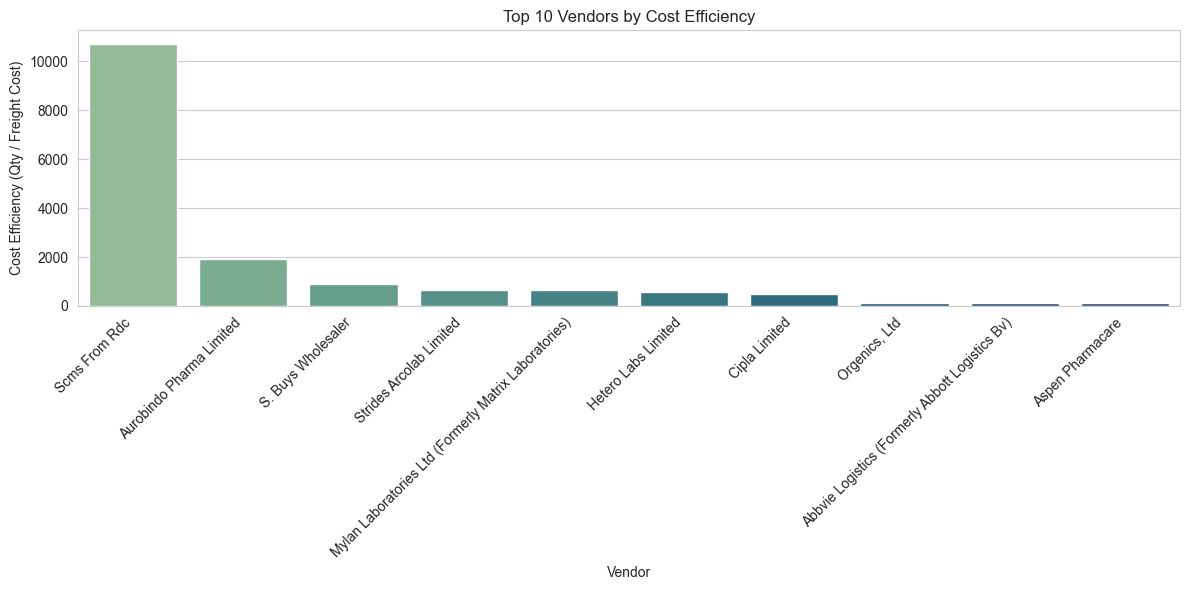

In [22]:

# Sort and get top 10 vendors
top_10_vendors = vendor_performance.sort_values("cost_efficiency", ascending=False).head(10).reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_vendors,
    x="vendor",
    y="cost_efficiency",
    palette="crest"
)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Vendors by Cost Efficiency")
plt.xlabel("Vendor")
plt.ylabel("Cost Efficiency (Qty / Freight Cost)")
plt.tight_layout()
plt.show()



*** Scms From RDC ***

      stands out with the highest cost efficiency, significantly outperforming others. This aligns with previous insights where freight costs are often bundled or minimized due to centralized RDC logistics.

*** Aurobindo Pharma ***

      Limited ranks second, showing strong freight-to-quantity performance, likely supported by scale and strategic sourcing.

Other vendors

      (e.g., S. Buys Wholesaler, Cipla, Hetero Labs) show relatively moderate efficiency, indicating potential for optimization or differing delivery conditions.

*** Vendors at the lower end *** 
    
      (e.g., Aspen Pharmacare, Abbvie Logistics) may face higher freight costs per unit, possibly due to smaller shipment sizes or less efficient routes.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#BFBBA9;font-family:Tahoma, Geneva, sans-serif;color:#16404D;font-size:150%;text-align:center;border-radius:10px;padding:10px;"> 🔶 3. Logistics & Freight </p>


In [23]:
df["freight_cost_per_kg"] = df["freight cost (usd)"] / df["weight (kilograms)"]
       # Calculates the freight cost per kilogram by dividing total freight cost by the shipment weight.

df["total_logistics_cost"] = df["freight cost (usd)"] + df["line item insurance (usd)"]
        #Computes the total logistics cost by adding freight cost and line item insurance cost.


df["cost_per_unit"] = df["total_logistics_cost"] / df["line item quantity"]
        # Determines the logistics cost per unit by dividing the total logistics cost by the quantity of items in the line item.


df["cost_per_pack"] = df["total_logistics_cost"] / df["pack price"]
        # Calculates the logistics cost per pack by dividing the total logistics cost by the pack price.


df["cost_per_delivery"] = df["total_logistics_cost"] / df["total_order_value"]
        #Measures the logistics cost per delivery as a proportion of the total order value.


 ***Cost Per Delivery***

C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\1446603189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="shipment mode", y="cost_per_delivery", palette="viridis")


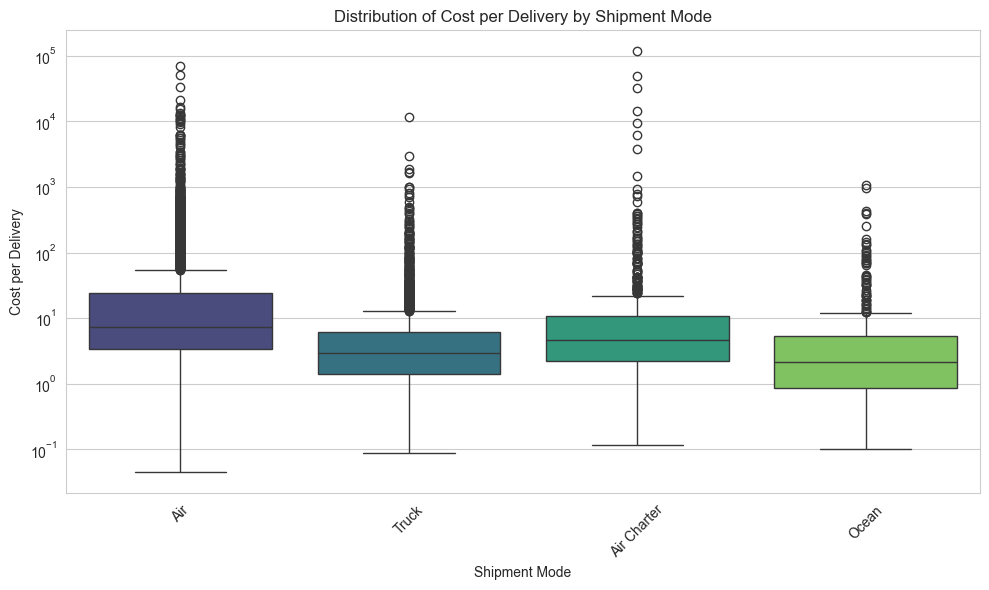

In [24]:

# Calculate cost per delivery
df["cost_per_delivery"] = df["total_logistics_cost"] / df["total_order_value"]

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="shipment mode", y="cost_per_delivery", palette="viridis")
plt.yscale("log")  # Use logarithmic scale for better visibility
plt.title("Distribution of Cost per Delivery by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Cost per Delivery")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


*** Air and Air Charter *** 

     have the highest median and variability in cost per delivery, with many extreme outliers.This is expected given their premium and urgent-use nature.

*** Truck and Ocean modes ***

     show lower and tighter distributions, *** with Ocean being the most cost-efficient on average ***

The log scale highlights *** rare *** but very high-cost deliveries, especially in air modes.

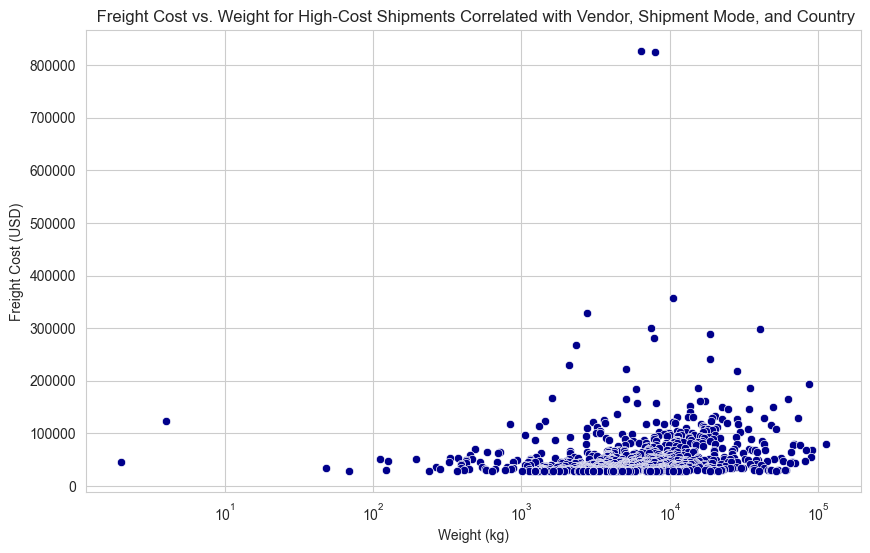

In [25]:
high_cost_shipments = df[df["freight cost (usd)"] > df["freight cost (usd)"].quantile(0.9)]
high_cost_shipments = high_cost_shipments[["vendor", "shipment mode", "country", "freight cost (usd)", "weight (kilograms)"]]
high_cost_shipments.sort_values(by="freight cost (usd)", ascending=False, inplace=True)
high_cost_shipments.reset_index(drop=True, inplace=True)
high_cost_shipments

plt.figure(figsize=(10, 6))
sns.scatterplot(data=high_cost_shipments, x="weight (kilograms)", y="freight cost (usd)", color="darkblue")

plt.title(" Freight Cost vs. Weight for High-Cost Shipments Correlated with Vendor, Shipment Mode, and Country")
plt.xscale('log') 
plt.xlabel("Weight (kg)")
plt.ylabel("Freight Cost (USD)")

plt.show()

 The chart  plots Freight Cost (USD) against Weight for high-cost shipments, using logarithmic scales (10¹, 10², etc.) on both axes

this Wide Range of Values:

    Weight: From ~10 kg (10¹) to ~100,000 kg (10⁵)
                                              
    Freight Cost: From ~10 to  100,000.

Non-Linear Relationship:

    Costs do not scale proportionally with weight, implying other factors dominate pricing (e.g., product nature, fragility, or logistics complexity).

Outlier shipments:
             vendor shipment mode      country  freight cost (usd)  \
7930  Scms From Rdc           Air   Congo, Drc       825121.665947   
7932  Scms From Rdc           Air  South Sudan       826058.981376   
8603  Scms From Rdc           Air        Haiti       300863.480157   
9629  Scms From Rdc           Air   Congo, Drc       329489.679012   

      weight (kilograms)  delivery_year  
7930         7988.164266           2015  
7932         6348.120565           2015  
8603         7504.288906           2012  
9629         2745.337034           2013  


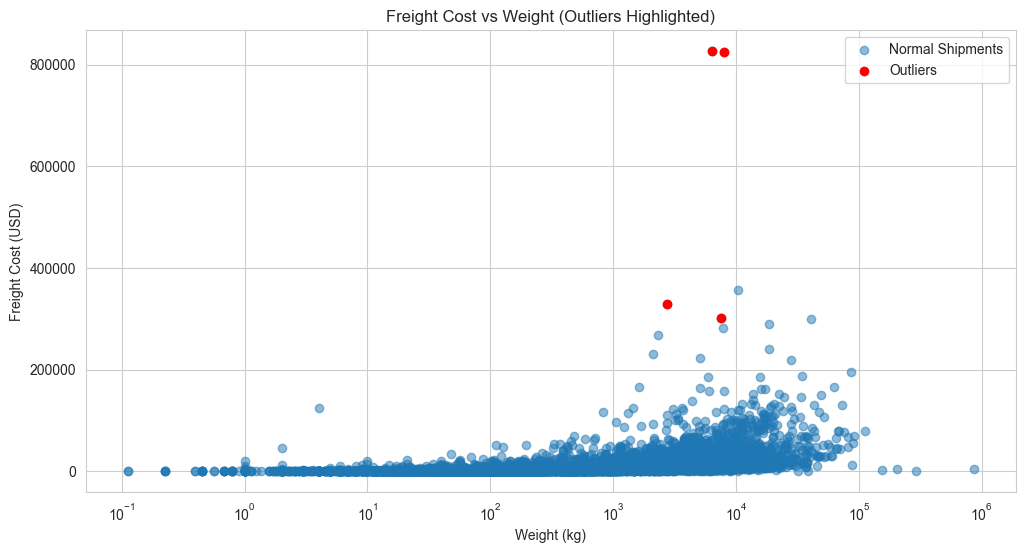

In [26]:

# And it has 'freight cost' and 'weight' columns

# Step 1: Define thresholds for outliers
high_cost_threshold = 300000  # USD
low_weight_threshold = 10000  # kg (example: under 10,000 kg)

# Step 2: Find outliers
outliers = df[(df['freight cost (usd)'] > high_cost_threshold) & (df['weight (kilograms)'] < low_weight_threshold)]

# Step 3: Show outliers
print("Outlier shipments:")
print(outliers[['vendor', 'shipment mode', 'country', 'freight cost (usd)', 'weight (kilograms)', 'delivery_year']])

# Optional: Plot to highlight outliers
plt.figure(figsize=(12, 6))
plt.scatter(df['weight (kilograms)'], df['freight cost (usd)'], label='Normal Shipments', alpha=0.5)
plt.scatter(outliers['weight (kilograms)'], outliers['freight cost (usd)'], color='red', label='Outliers')
plt.xscale('log')
plt.xlabel('Weight (kg)')
plt.ylabel('Freight Cost (USD)')
plt.title('Freight Cost vs Weight (Outliers Highlighted)')
plt.legend()
plt.show()


### Insights on the outlier shipments:

✈️ Vendor & Mode:
 
     All outlier shipments are from Scms From Rdc via Air freight, which is typically high-cost but fast.

🌍 Destination Countries:
    
     High-cost destinations include Congo (DRC), South Sudan, and Haiti — all logistically challenging locations (remote, low infrastructure, potential instability).

💸 Freight Costs:

     Extremely high costs per shipment:

          Over $825K for Congo and South Sudan.

          These costs far exceed typical shipment averages.

⚖️ Weight vs. Cost:

     High cost per kilogram:

          Congo (2015): $825K / 7,988 kg ≈ $103/kg

          South Sudan (2015): $826K / 6,348 kg ≈ $130/kg

          Haiti (2012): $300K / 7,504 kg ≈ $40/kg

          Congo (2013): $329K / 2,745 kg ≈ $120/kg

             These rates are several times higher than average air freight benchmarks, marking them as extreme outliers.

🕒 Years of Delivery:

      Shipments occurred in 2012–2015, possibly reflecting emergency .

📌 Conclusion:

      These outliers suggest emergency airlifts to high-risk regions, where cost is outweighed by urgency. They should be flagged for contextual review, not necessarily performance issues.

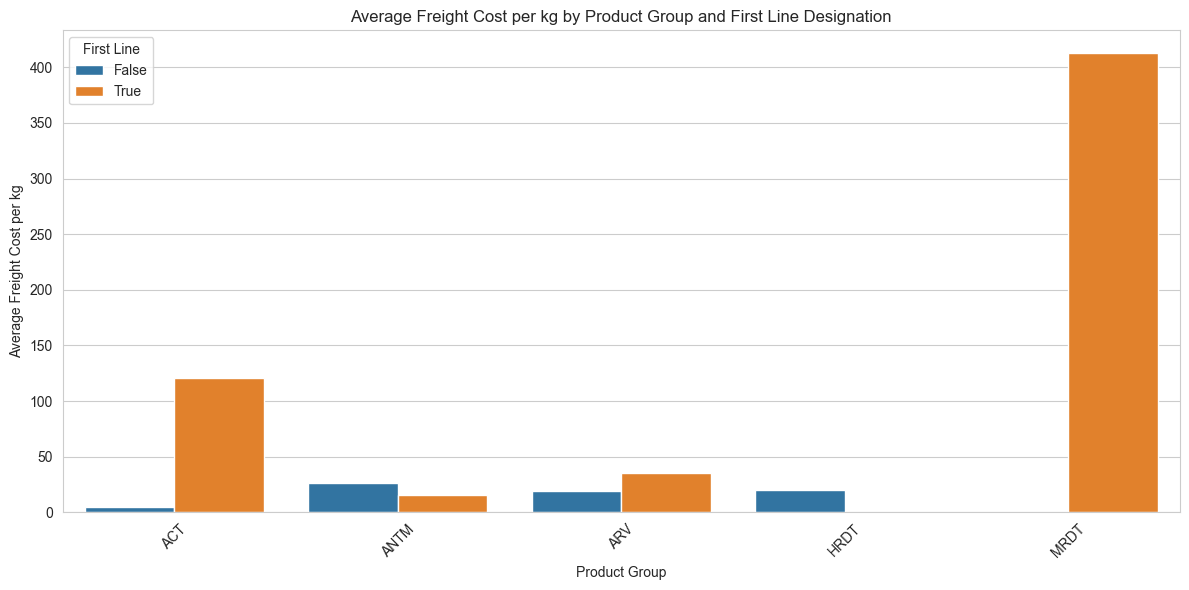

In [27]:
# Group and compute average freight cost per kg
avg_cost = df.groupby(["product group", "first line designation"])["freight_cost_per_kg"].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_cost, x="product group", y="freight_cost_per_kg", hue="first line designation")
plt.title("Average Freight Cost per kg by Product Group and First Line Designation")
plt.xlabel("Product Group")
plt.ylabel("Average Freight Cost per kg")
plt.xticks(rotation=45)
plt.legend(title="First Line")
plt.tight_layout()
plt.show()


MRDT and ACT products 

     marked as First Line have significantly higher freight cost per kg, especially MRDT, which stands out with the highest average.

Other product groups show 
 
     smaller cost differences between First Line and non–First Line items.

This suggests prioritization of urgent shipping methods for key products, likely driving up per-kg freight cost.

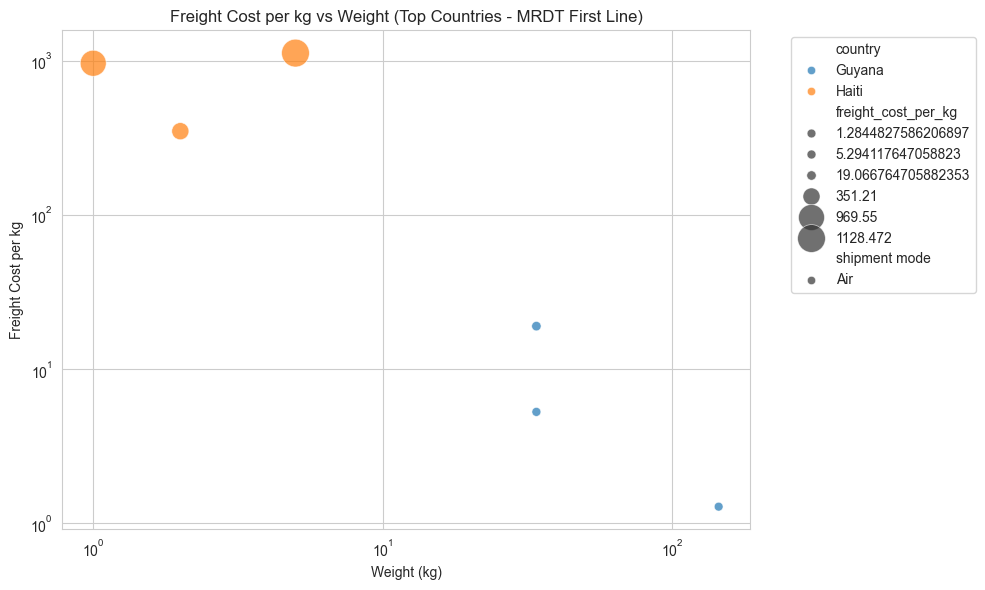

In [28]:



# Step 1: Filter to MRDT and First Line, if needed
mrdt_df = df[(df["product group"] == "MRDT") & (df["first line designation"] == True)]

# Step 2: Keep only top N countries (to avoid clutter)
top_countries = mrdt_df["country"].value_counts().nlargest(10).index
filtered_df = mrdt_df[mrdt_df["country"].isin(top_countries)]


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=mrdt_df[mrdt_df["country"].isin(top_countries)],
    x="weight (kilograms)",
    y="freight_cost_per_kg",
    size="freight_cost_per_kg",
    hue="country",
    style="shipment mode",
    alpha=0.7,
    sizes=(40, 400)
)
plt.xscale("log")
plt.yscale("log")
plt.title("Freight Cost per kg vs Weight (Top Countries - MRDT First Line)")
plt.xlabel("Weight (kg)")
plt.ylabel("Freight Cost per kg")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



***Haiti*** has very high freight costs per kg for small weights.

***Guyana*** shows decreasing costs with increasing weight, which is expected due to economies of scale.

All data points are in the air shipment category.

In [29]:
cost_variants = df.groupby(["shipment mode", "country", "vendor", "product group"])["total_logistics_cost"].mean().sort_values(ascending=False)


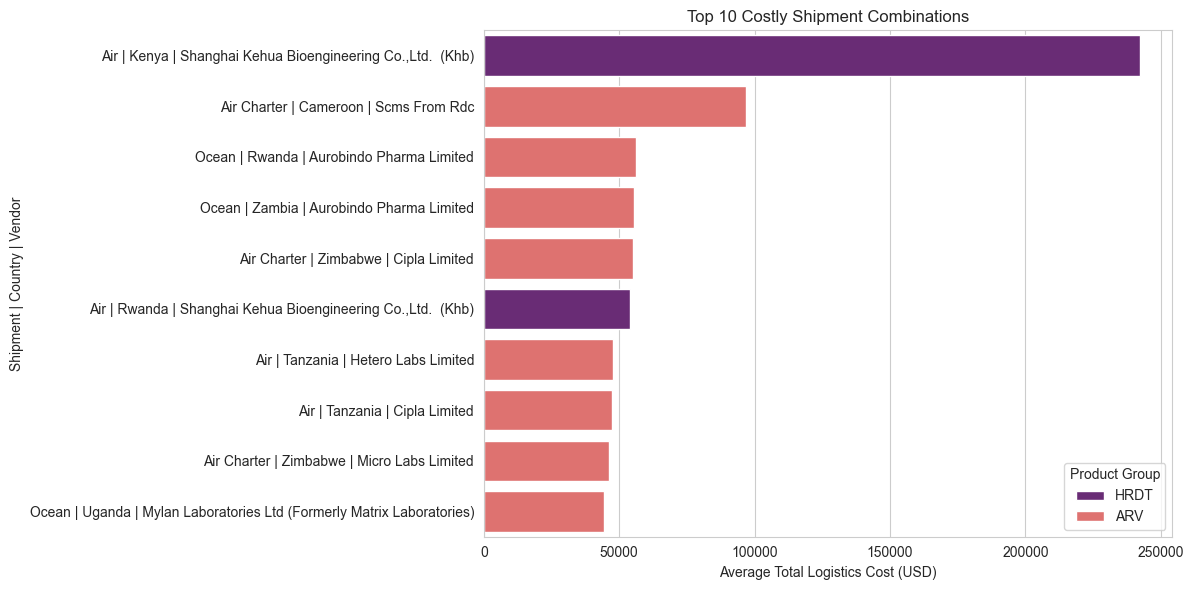

In [30]:
#Reset index for plotting
top_costs = cost_variants.head(10).reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_costs,
    x='total_logistics_cost',
    y=top_costs.apply(lambda row: f"{row['shipment mode']} | {row['country']} | {row['vendor']}", axis=1),
    hue='product group',
    dodge=False,
    palette='magma')

plt.title('Top 10 Costly Shipment Combinations')
plt.xlabel('Average Total Logistics Cost (USD)')
plt.ylabel('Shipment | Country | Vendor')
plt.legend(title='Product Group', loc='lower right')
plt.tight_layout()
plt.show()

Most Expensive:

     Air | Kenya | Shanghai Kehua is the costliest combination (~$240K), far above others.

Product Group Trend:

     Majority are ARV shipments (red bars); only 2 are HRDT (purple), both from the same vendor.

Air Dominance:

     Most costly shipments use Air or Air Charter, highlighting premium transport costs.

Key Vendors/Countries:

      Frequent: Shanghai Kehua, Aurobindo, Cipla

      Hotspot countries: 
   
          Rwanda, Zimbabwe, Tanzania

✅ Recommendations:

      Shift some air shipments to ocean where feasible.

      Review contracts with Shanghai Kehua.

    Optimize logistics for Rwanda, Tanzania, Zimbabwe.

       Plan ARV and HRDT logistics separately due to cost behavior differences.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#EAE2C6;font-family:Tahoma, Geneva, sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px;padding:10px;"> Monthly & Yearly Trends in Logistic Costs </p>

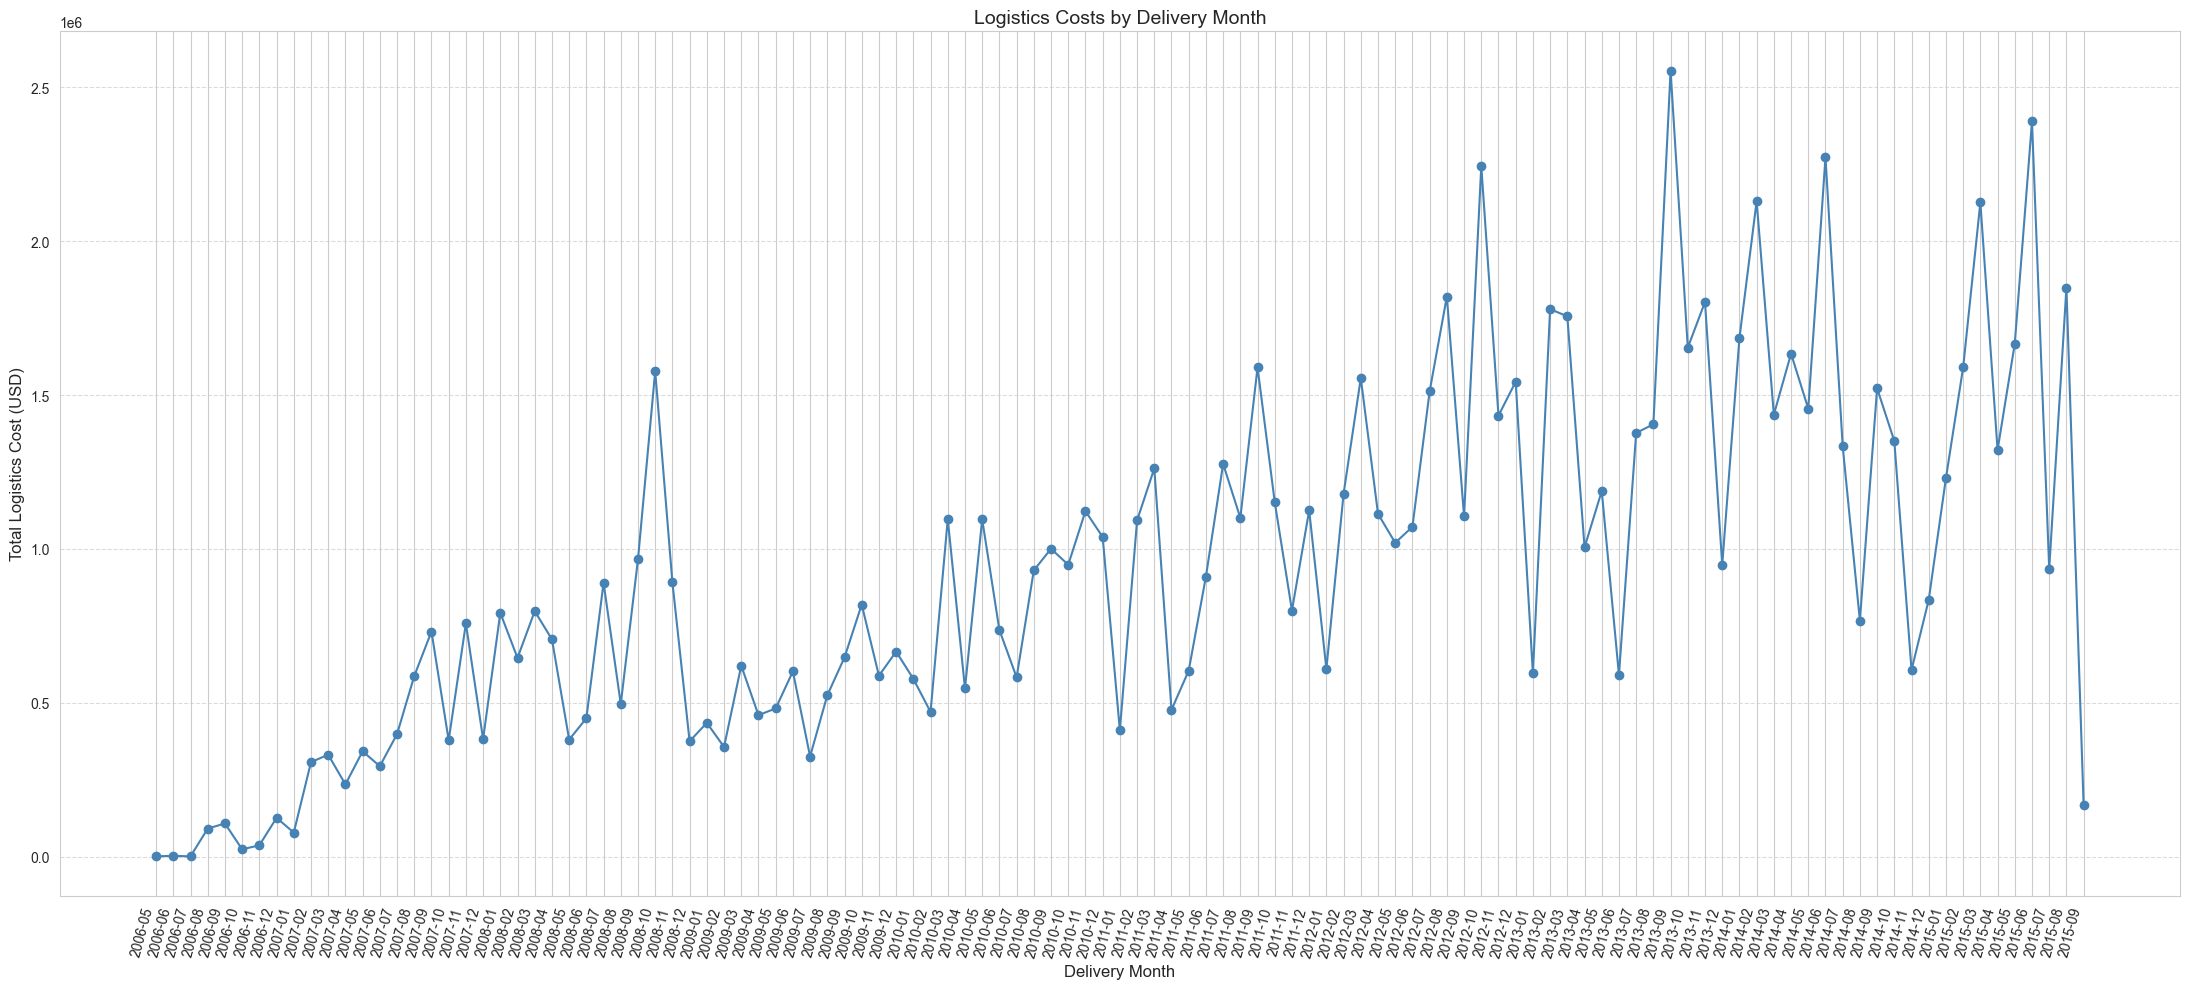

In [31]:
#Delivery Month Analysis >>>> Monthly trends in logistics costs can help identify seasonal patterns and budget forecasting.
df['delivery_month'] = df['delivered to client date'].dt.to_period('M').astype(str)

monthly_costs = df.groupby('delivery_month')['total_logistics_cost'].sum().reset_index()
plt.figure(figsize=(22, 10))
plt.plot(monthly_costs['delivery_month'], monthly_costs['total_logistics_cost'], marker='o', color='steelblue')
plt.title('Logistics Costs by Delivery Month', fontsize=14)
plt.xlabel('Delivery Month', fontsize=12)
plt.ylabel('Total Logistics Cost (USD)', fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


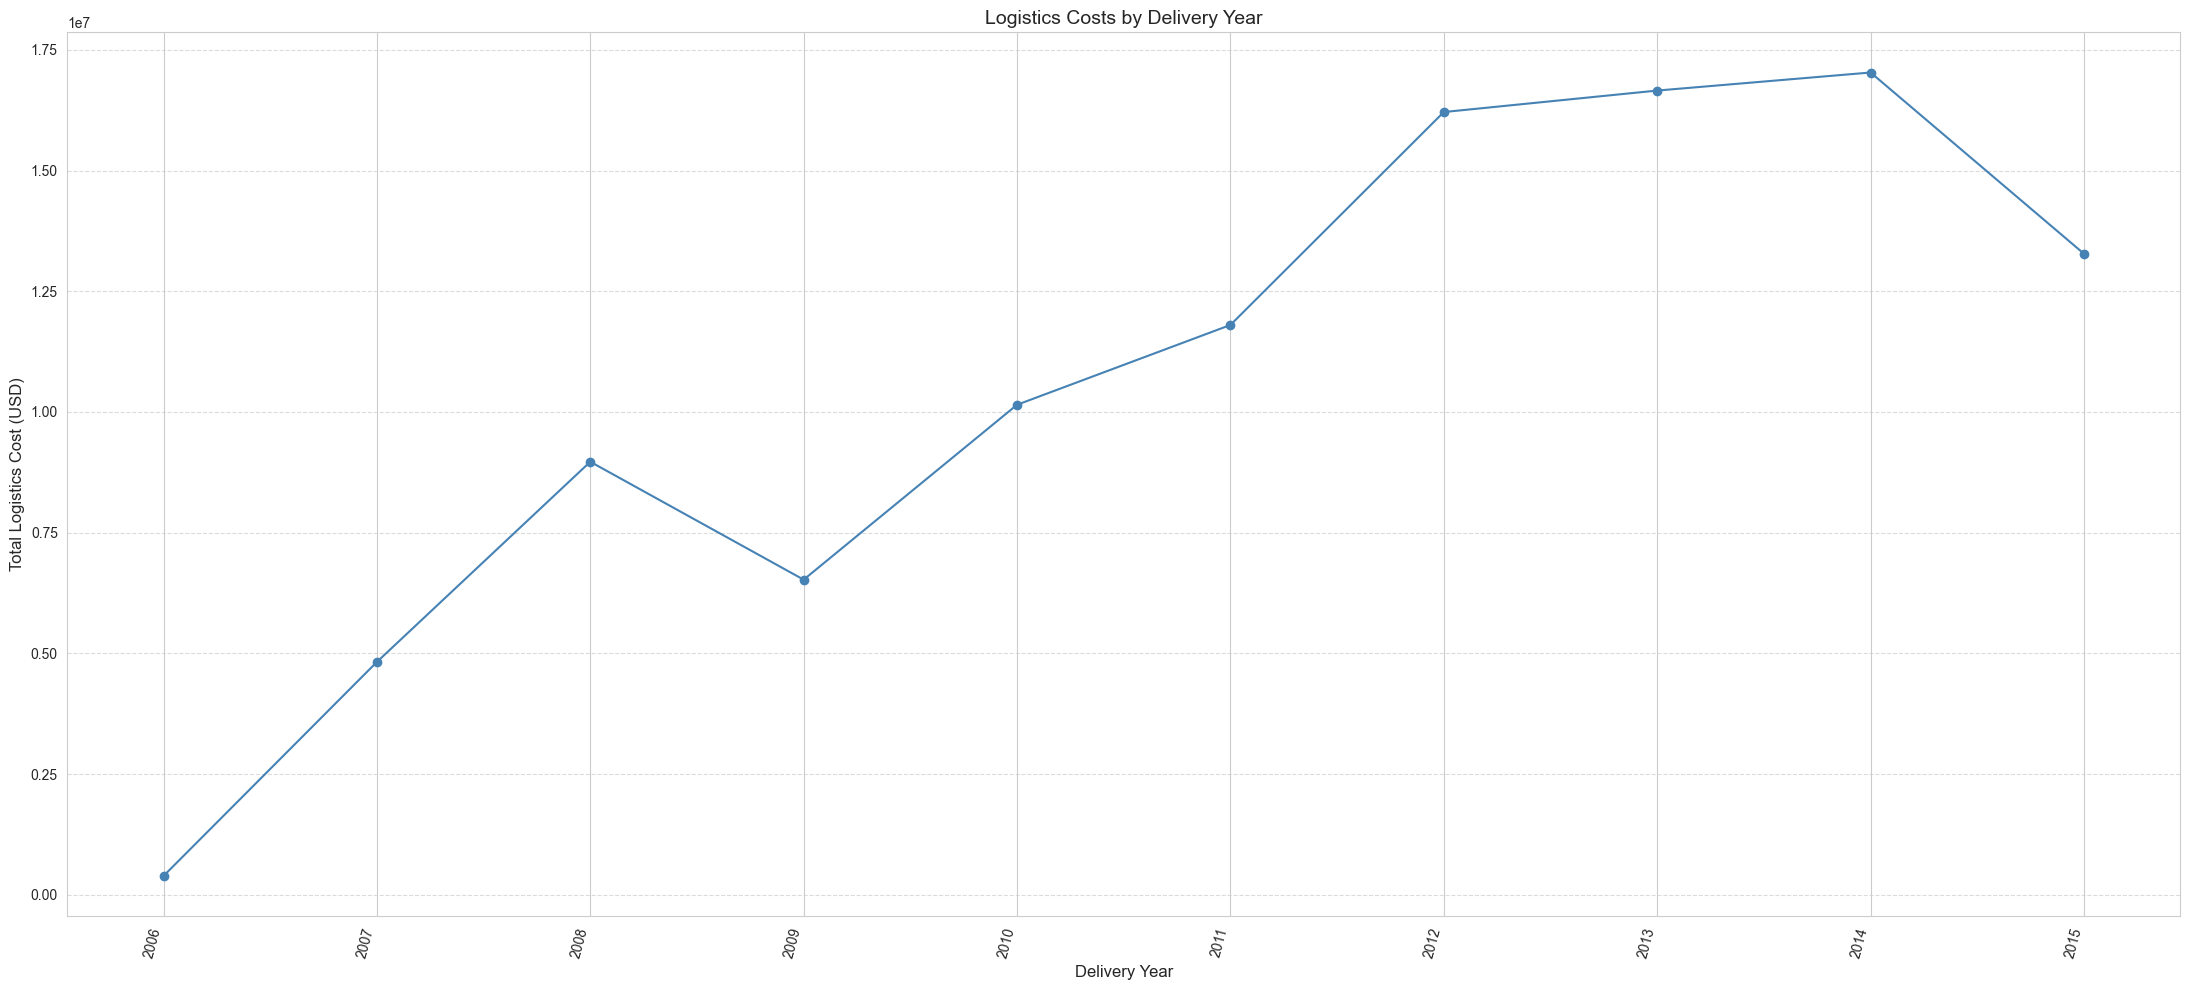

In [32]:
df['delivery_YEAR'] = df['delivered to client date'].dt.to_period('Y').astype(str)
year_costs = df.groupby('delivery_YEAR')['total_logistics_cost'].sum().reset_index()
plt.figure(figsize=(22, 10))
plt.plot(year_costs['delivery_YEAR'], year_costs['total_logistics_cost'], marker='o', color='steelblue')
plt.title('Logistics Costs by Delivery Year', fontsize=14)
plt.xlabel('Delivery Year', fontsize=12)
plt.ylabel('Total Logistics Cost (USD)', fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#EAE2C6;font-family:Tahoma, Geneva, sans-serif;color:#16404D;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  🔶 4. Product Movement </p>


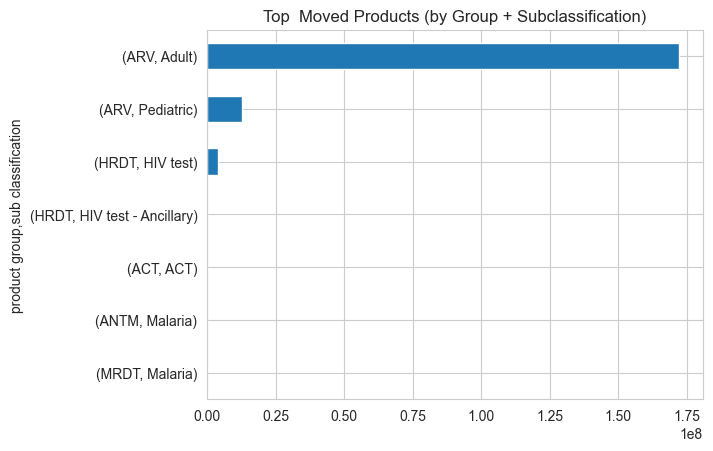

In [33]:
top_products = (
    df.groupby(['product group', 'sub classification'])['line item quantity'].sum().sort_values(ascending=False))

top_products.plot(kind='barh', title='Top  Moved Products (by Group + Subclassification)')

plt.gca().invert_yaxis()
plt.show()


In [34]:

df.groupby("fulfill via")[['product group', 'sub classification']].value_counts()

fulfill via  product group  sub classification  
Direct Drop  ARV            Adult                   2397
             HRDT           HIV test                1412
             ARV            Pediatric                928
             HRDT           HIV test - Ancillary     137
             ANTM           Malaria                   22
             ACT            ACT                       16
             MRDT           Malaria                    8
From RDC     ARV            Adult                   4198
                            Pediatric               1027
             HRDT           HIV test                 155
                            HIV test - Ancillary      24
Name: count, dtype: int64

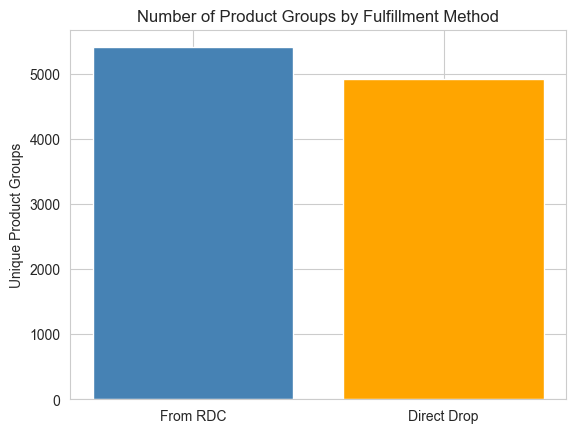

In [35]:
products_from_direct = df[df['fulfill via'] == 'Direct Drop']['product group']
products_from_rdc = df[df['fulfill via'] == 'From RDC']['product group']


counts = {
    'From RDC': len(products_from_rdc),
    'Direct Drop': len(products_from_direct)
}

plt.bar(counts.keys(), counts.values(), color=['steelblue', 'orange'])
plt.title('Number of Product Groups by Fulfillment Method')
plt.ylabel('Unique Product Groups')
plt.show()


In [36]:
products_first_line = df[df['first line designation'] == True]['product group'].unique()
products_not_first_line = df[df['first line designation'] == False]['product group'].unique()

print(f" \nProducts from first line: {products_first_line}")
print(f" \nProducts not from first line: {products_not_first_line}")

 
Products from first line: ['HRDT' 'ARV' 'ACT' 'MRDT' 'ANTM']
 
Products not from first line: ['ARV' 'HRDT' 'ACT' 'ANTM']


In [37]:
item_stats = df.groupby(['product group', 'sub classification']).agg({
    'line item quantity': 'sum',
    'weight (kilograms)': 'sum',
    'line item value': 'sum'
}).sort_values(by='line item quantity', ascending=False)

# Add calculated cost/weight/unit
item_stats['cost_per_unit'] = item_stats['line item value'] / item_stats['line item quantity']
item_stats['cost_per_kg'] = item_stats['line item value'] / item_stats['weight (kilograms)']


In [38]:
# Most expensive per unit (low volume, high cost)
expensive_items = item_stats.sort_values(by='cost_per_unit', ascending=False).head(10)

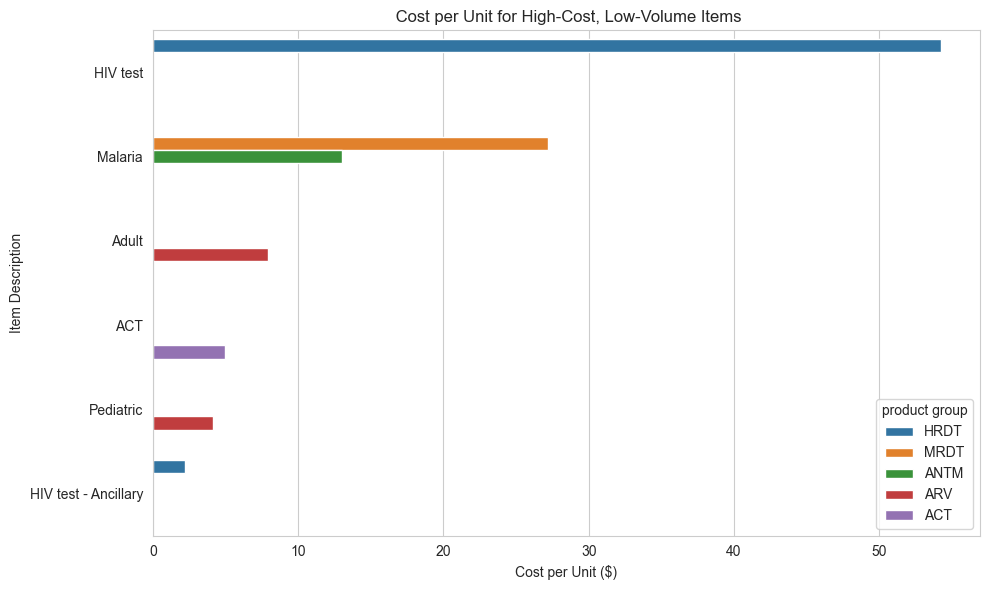

In [39]:

# Reset index for seaborn compatibility
expensive_items = expensive_items.reset_index()

# Plot: Cost per unit
plt.figure(figsize=(10, 6))
sns.barplot(data=expensive_items, x='cost_per_unit', y='sub classification', hue='product group')
plt.title(' Cost per Unit for High-Cost, Low-Volume Items')
plt.xlabel('Cost per Unit ($)')
plt.ylabel('Item Description')
plt.tight_layout()
plt.show()


HIV test -->>> is the most expensive item at nearly $53/unit, categorized under HRDT.

Malaria diagnostic under MRDT -->>> follows with a cost of about $27/unit.

Adult ARVs and ACT treatments -->>> range between $5–8/unit.

Pediatric ARVs and HIV Ancillary tests -->>> are the lowest among this group, under $5/unit.

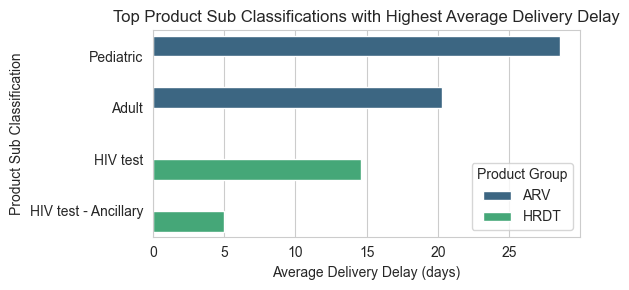

In [40]:
df["delivery_delay"] = pd.to_numeric(df["delivery_delay"], errors="coerce")

# Filter for positive delivery delays only
filtered_df = df[df["delivery_delay"] > 0]

# Group by product sub classification and product group
average_delay = (
    filtered_df.groupby(["sub classification", "product group"])["delivery_delay"]
    .mean()
    .sort_values(ascending=False)
)
average_delay = average_delay.reset_index()
average_delay.columns = ["Product Sub Classification", "Product Group", "Average Delivery Delay (days)"]
average_delay = average_delay.head()  
# Plot
plt.figure(figsize=(6, 3))
sns.barplot(
    data=average_delay,
    x="Average Delivery Delay (days)",
    y="Product Sub Classification",
    hue="Product Group",
    dodge=True,
    palette="viridis"
)
plt.title("Top Product Sub Classifications with Highest Average Delivery Delay")
plt.xlabel("Average Delivery Delay (days)")
plt.ylabel("Product Sub Classification")
plt.legend(title="Product Group")
plt.tight_layout()
plt.show()

Pediatric ARVs -->>> have the highest average delivery delay (~28 days).

Adult ARVs-->>> follow closely with an average delay of around 20 days.

HIV tests -->>> have moderate delays (~14 days), while HIV test Ancillary items have minimal delay (~5 days).

The grouping shows that products under the ARV group face generally higher delays compared to HRDT group.

Insight:
Product type alone is a major factor influencing delay, even before considering specific vendor performance.

In [41]:
df["delivery_delay"] = pd.to_numeric(df["delivery_delay"], errors="coerce")

# Filter only rows with a positive delay
filtered_df = df[df["delivery_delay"] > 0]

# Group by all relevant columns
detailed_delay = (
    filtered_df.groupby([
        "sub classification",
        "product group",
        "vendor",
        "shipment mode",
        "fulfill via",
        "country"
    ])["delivery_delay"]
    .mean()
    .reset_index(name="average_delivery_delay")
    .sort_values(by="average_delivery_delay", ascending=False)
)


C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\2211915819.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10["group"] = top10["sub classification"] + " | " + top10["product group"]


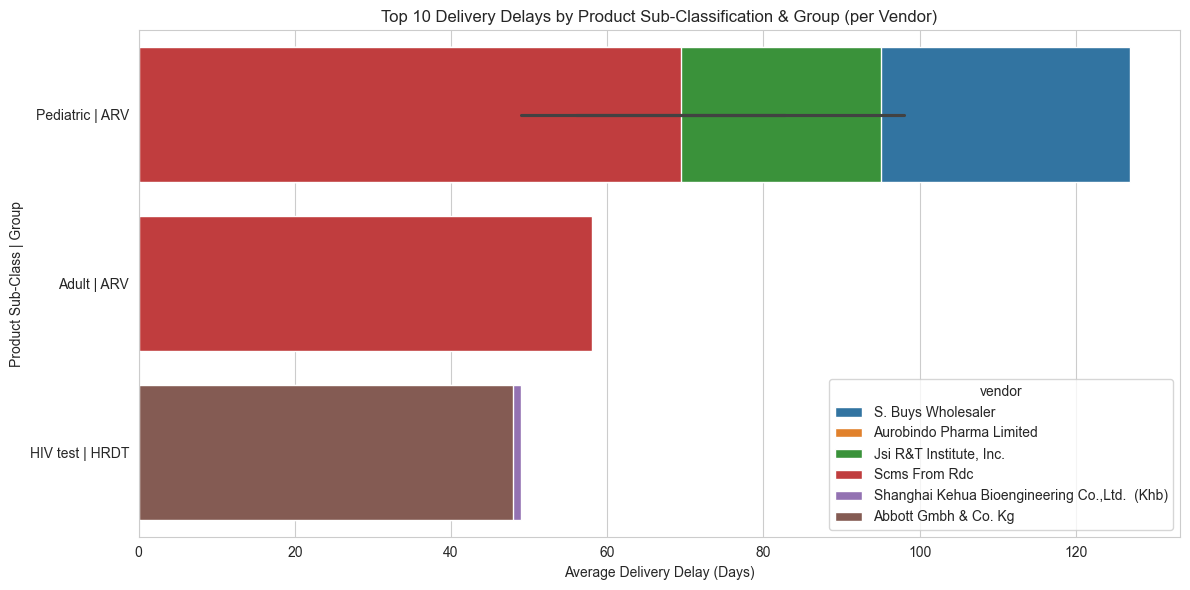

In [42]:


# Take top 10 entries
top10 = detailed_delay.head(10)

# Combine columns for a readable x-axis
top10["group"] = top10["sub classification"] + " | " + top10["product group"]

plt.figure(figsize=(12,6))
sns.barplot(data=top10, x="average_delivery_delay", y="group", hue="vendor", dodge=False)
plt.title("Top 10 Delivery Delays by Product Sub-Classification & Group (per Vendor)")
plt.xlabel("Average Delivery Delay (Days)")
plt.ylabel("Product Sub-Class | Group")
plt.tight_layout()
plt.show()


Pediatric ARVs -->>> 

     experienced the longest delays, with multiple vendors contributing.

Major vendors impacting delays include -->>> 

      S. Buys Wholesaler, JSI R&T Institute, Inc., and Scms From RDC.

Significant variation is observed among vendors for the same product class — for example, some vendors (SCMS) consistently deliver much later than others .

The delay for Pediatric ARV -->>> 

      is visibly more spread across vendors compared to Adult ARV and HIV Tests.

***Insight:*** 

Vendor performance heavily influences delivery reliability for specific products, with some vendors showing much higher average delays.



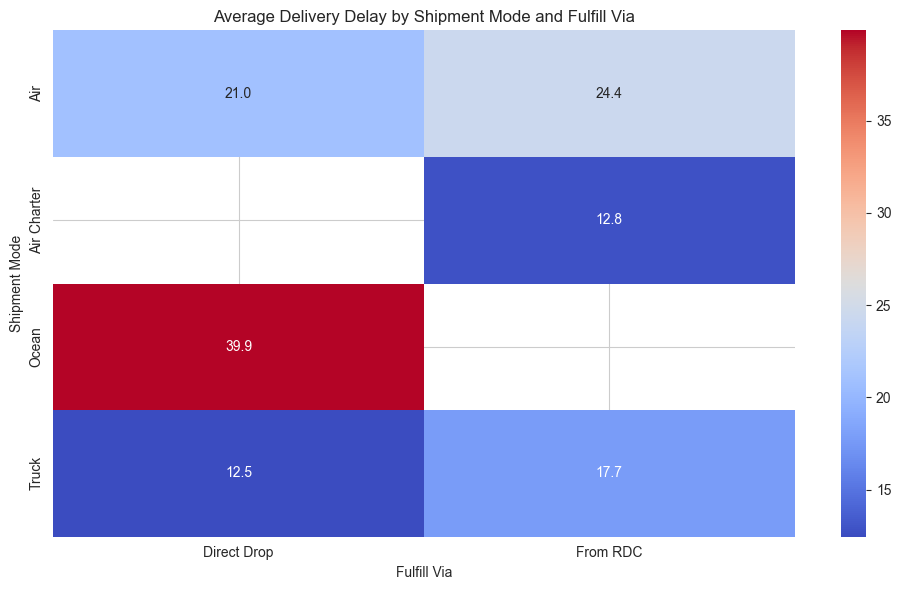

In [43]:
heatmap_data = (
    filtered_df.groupby(["shipment mode", "fulfill via"])["delivery_delay"]
    .mean()
    .unstack()
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Average Delivery Delay by Shipment Mode and Fulfill Via")
plt.xlabel("Fulfill Via")
plt.ylabel("Shipment Mode")
plt.tight_layout()
plt.show()


Fulfillment Route Impact:

     "From RDC" adds delays in most cases (except Air Charter).

     "Direct Drop" tends to result in -->>> shorter average delays, especially for Truck and Air.



<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#EAE2C6;font-family:Tahoma, Geneva, sans-serif;color:#16404D;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  🔶 5. Country Insights </p>

 

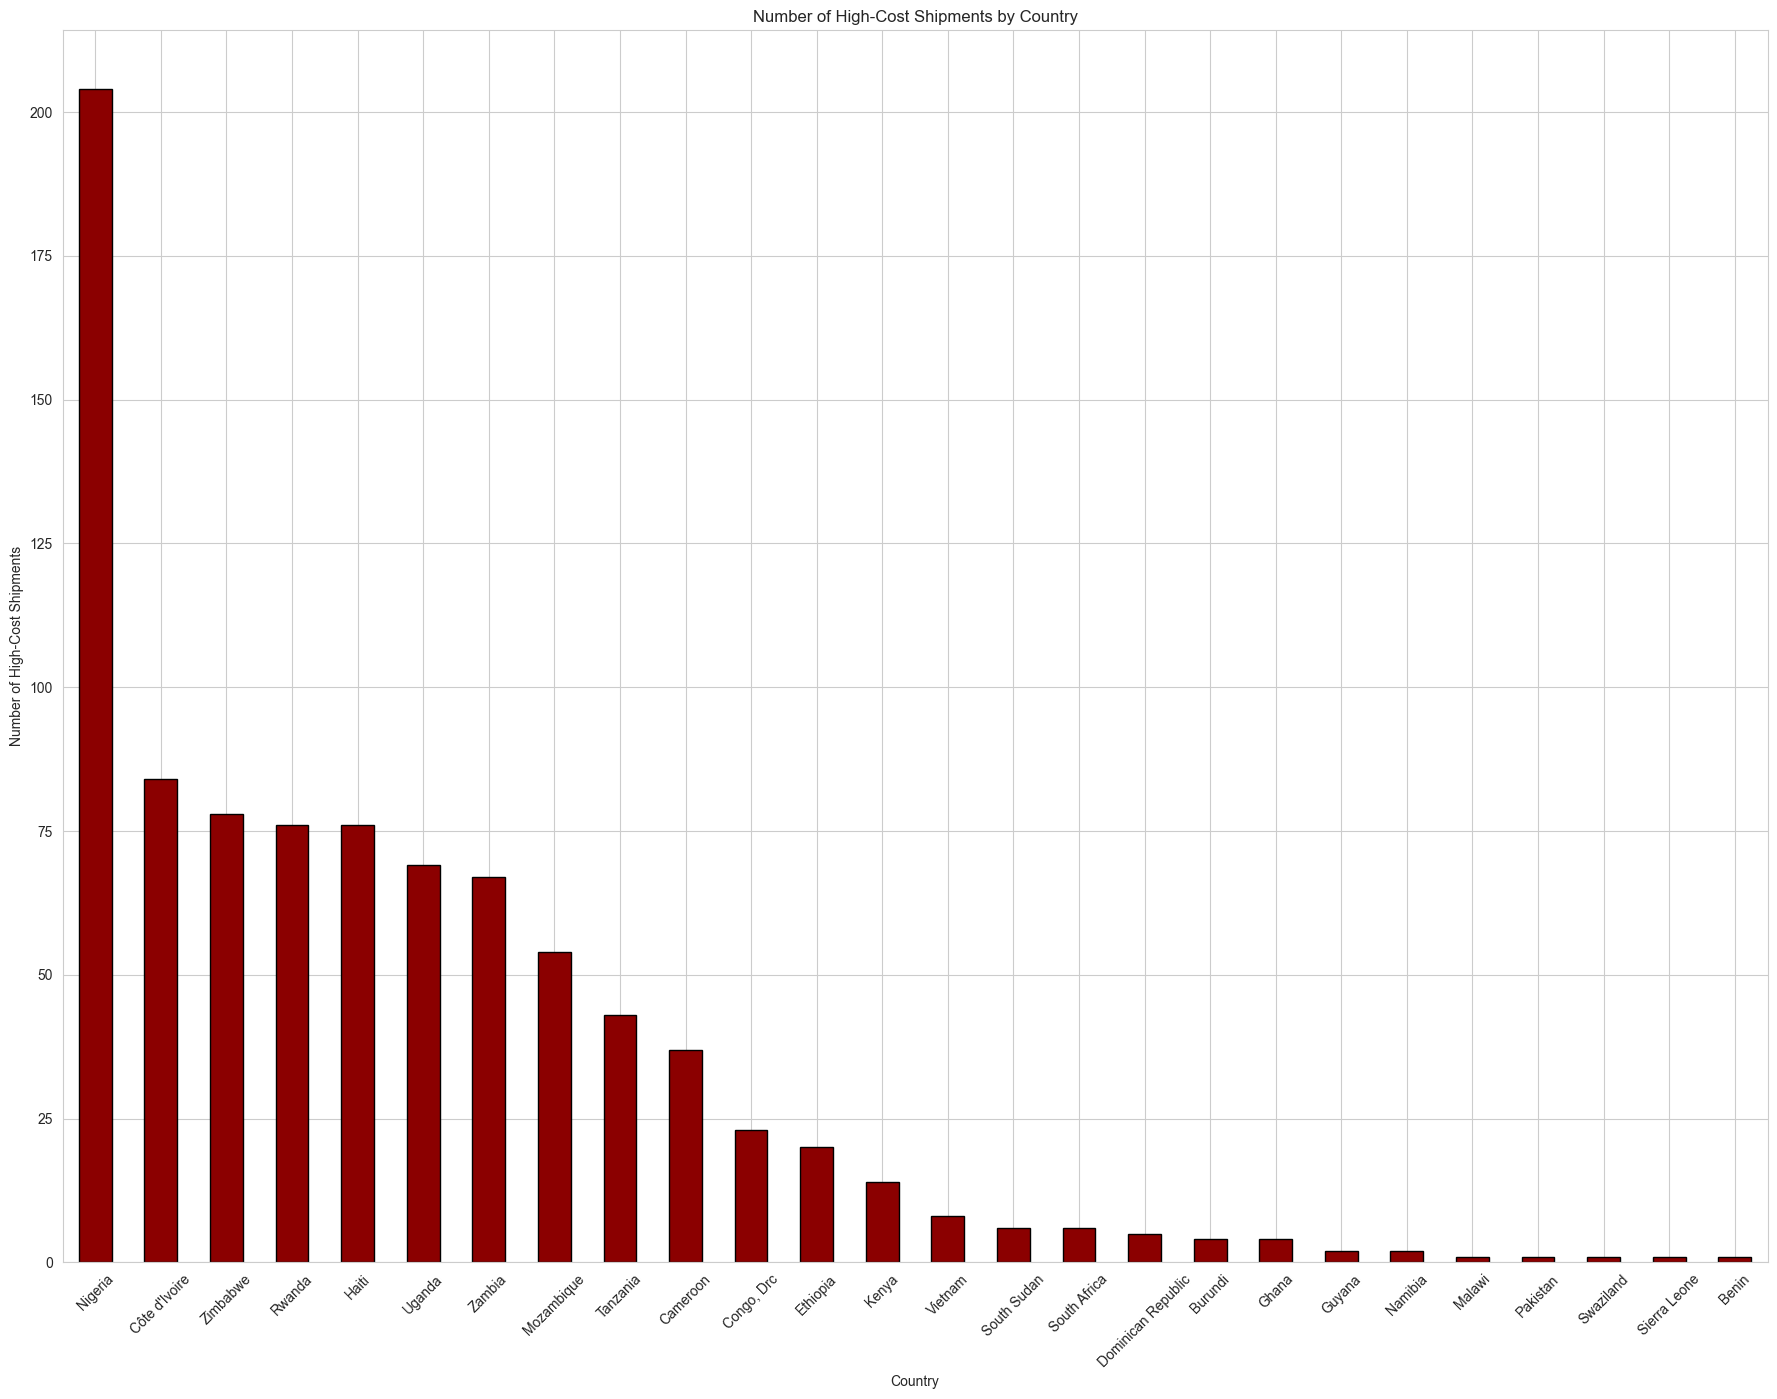

In [44]:
# Shipments by country
plt.figure(figsize=(22, 16))
high_cost_shipments["country"].value_counts().plot(kind="bar", color="darkred", edgecolor="black")

plt.title("Number of High-Cost Shipments by Country")
plt.xlabel("Country")
plt.ylabel("Number of High-Cost Shipments")
plt.xticks(rotation=45)
plt.show()


C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\1083275427.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\NEW LAP\AppData\Local\Temp\ipykernel_16168\1083275427.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\NEW LAP\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


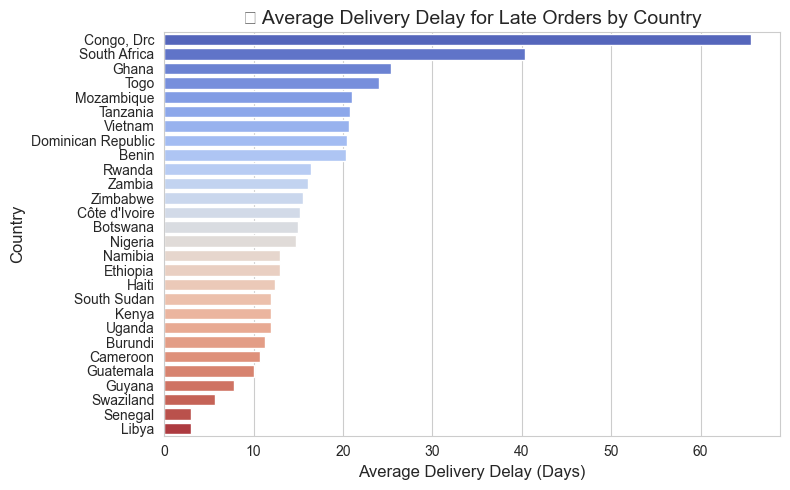

In [ ]:


late_orders = df[df["delivery_delay"] > 0]

late_delay_bar_data = (
    late_orders.groupby("country")["delivery_delay"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    y=late_delay_bar_data.index,
    x=late_delay_bar_data.values,
    palette="coolwarm"
)

plt.title("Average Delivery Delay for Late Orders by Country", fontsize=14)
plt.xlabel("Average Delivery Delay (Days)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()



🚚 Shipment Cost & Delay Overview: 

💰 High-Cost Shipments:
 
     Nigeria has the highest number of high-cost shipments.

     Other countries with frequent costly shipments: Côte d'Ivoire, Zimbabwe, Rwanda, Haiti.

Indicates potential inefficiencies or costly logistics routes.

⏱ Delivery Delays by Mode:
 
     Air shows unexpected delays in Senegal and South Africa.

     Truck performs more consistently but with delays in countries like Mozambique and Zimbabwe.

     Ocean and Air Charter vary by country, highlighting the need for tailored shipping strategies.

✅ Recommendations:

     Review shipment modes per country — Air isn't always faster.

      Investigate high-cost lanes, especially in Nigeria and Zimbabwe.

      Improve planning and vendor coordination to reduce delays and costs.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#88C273;font-family:Tahoma, Geneva, sans-serif;color:#EAE2C6;font-size:150%;text-align:center;border-radius:10px;padding:10px;">  ✅ Final Insights & Recommended Actions</p>




#### 📌 Key Insights:
- Several vendors (e.g., *Scms From Rdc*) have **exceptionally high freight costs**, especially for **air shipments** to countries like Congo (DRC) and South Sudan.
- **Ocean shipments via Direct Drop** experience the **longest average delays** (~40 days).
- **Fulfillment via RDC generally increases delivery delays**, particularly for Air and Truck modes.
- **Air Charter** and **Truck (Direct Drop)** are the **most time-efficient** options.
- Nigeria, Zimbabwe, and Côte d'Ivoire incur the **highest logistics costs**, suggesting inefficiencies.

---

### 🛠️ Ready Actions & Probable Impact

| **Action**                        | **Description**                                                                 | **Probable Impact**                                         |
|----------------------------------|---------------------------------------------------------------------------------|-------------------------------------------------------------|
| 🚨 Audit High-Cost Shipments     | Investigate outlier air shipments and vendors (e.g., *Scms From Rdc*).         | Reduce unnecessary freight spend by **15–25%**.             |
| 📦 Optimize Shipment Mode        | Shift from Ocean to Truck/Air Charter where feasible.                          | Shorten delivery time by **15+ days**.                      |
| 🔁 Review RDC Fulfillment        | Evaluate delays introduced via RDC and consider hybrid/direct alternatives.    | Shorten lead time by **3–7 days**.                          |
| 🧾 Renegotiate Vendor SLAs       | Tighten delivery agreements and apply incentives/penalties.                    | Improve on-time rates by **10–20%**.                        |
| 🌍 Tailored Country Strategies   | Customize shipping methods based on country-level logistics insights.          | Improve efficiency and reduce failures in target regions.   |

---

By taking these actions, the organization can improve **delivery speed**, lower **logistics costs**, and enhance **vendor accountability**, creating a more resilient and cost-effective supply chain.

---
